# TP2 - Análise de Desempenho de Técnicas de Aprendizagem Automática
**Análise Discreta | ISEP 2025/2026**

**Turma 3DH - Grupo 8:** Mariana Martins 1230679 | Luna Gomes 1231651 | Samara Miranda 1230432

**Tema:** Impacto da Eficiência Energética na Iluminação Pública na Reserva de Potência dos PTDs e Viabilidade de Mobilidade Elétrica

---
### Continuidade com o TP1

O TP1 realizou uma análise estatística exploratória **ao nível do concelho**, definindo as seguintes métricas de engenharia que são usadas no TP2 ao nível do PTD individual:

| Variável TP1 | Fórmula (TP1) | Variável TP2 (PTD level) | Observação |
|---|---|---|---|
| Ganho LED (ΔP_LED) | `P_IP_Inef × 0.65` | `Ganho_LED_PTD` | Já calculado no dataset |
| Folga Rede (P_Folga) | `Cap_PTD × 0.92 × (1 − Util_Media)` | `PFolga_PTD` | Margem de segurança 92% |
| Carga VE (P_VE) | `N_PTDs × 22kW × 0.60` | `PVE_PTD = 13.2 kW` | Por PTD, fator simult. 60% |
| Saldo sem LED (D) | `P_Folga − P_VE` | `D_PTD` | Já calculado |
| Saldo com LED (D_LED) | `P_Folga + ΔP_LED − P_VE` | `D_PTD_LED` | Já calculado |
| Rate Ineficiência | `P_IP_Inef / P_IP_Total` | `Rate_Ineficiencia` | Já calculado |

**Contexto do TP1:** O modelo OLS (Regressão Linear Múltipla) obteve R²_adj = 6.4%, evidenciando que a análise agregada ao nível do concelho tem baixo poder explicativo - o que motiva a passagem para análise ao nível do PTD individual com técnicas de ML.

## Setup - Imports e Configuração

In [2]:
!pip install scikit-learn tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, learning_curve, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import shapiro, ttest_rel, wilcoxon

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

USE_SAMPLE  = True   # True: usa subsample; False: dataset completo
SAMPLE_SIZE = 15000   # tamanho do subsample

print('Setup concluído. TF:', tf.__version__)

Setup concluído. TF: 2.21.0


---
## 4.1. Análise Exploratória de Dados (EDA)
### 4.1.1 - Carregar dataset e sumário

In [3]:
df = pd.read_excel('PTD_level_dataset.xlsx')
print('Dimensão:', df.shape)
df.head()

Dimensão: (72027, 32)


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [4]:
# Sumário de nulos
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print('Colunas com valores omissos:')
print(info_df[info_df['nulos'] > 0].to_string())
print('\nEstatísticas descritivas (variáveis chave do TP1 e TP2):')
key_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef',
            'Rate_Ineficiencia', 'LED_Ratio', 'Ganho_LED_PTD',
            'PFolga_PTD', 'PVE_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']
df[key_cols].describe().round(4)

Colunas com valores omissos:
                           dtype  nulos  nulos_%
Pot_Contratada_kVA       float64  21180    29.41
Pot_Geracao_kW           float64  70191    97.45
D_PTD                    float64   3064     4.25
D_PTD_LED                float64   3064     4.25
PContratada_per_Cliente  float64  21180    29.41
Geracao_per_Cliente      float64  70191    97.45
Util_Decimal             float64   3064     4.25
PFolga_PTD               float64   3064     4.25

Estatísticas descritivas (variáveis chave do TP1 e TP2):


,Cap_PTD_kVA,N_Clientes,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,Ganho_LED_PTD,PFolga_PTD,PVE_PTD,D_PTD,D_PTD_LED,Util_Decimal
count,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,68963.0000,72027.0,68963.0000,68963.0000,68963.0000
mean,302.7988,94.6980,1381.4902,463.2906,0.2807,0.6717,0.5569,147.9833,13.2,134.7833,135.3433,0.5138
std,294.4445,110.0551,1723.7106,708.0096,0.2404,0.2731,0.6874,186.7599,0.0,186.7599,186.8503,0.2470
min,0.0000,20.0000,23.2186,0.0000,0.0000,0.0117,0.0000,0.0000,13.2,-13.2000,-13.2000,0.1900
25%,100.0000,20.0000,382.5690,28.9850,0.0642,0.5007,0.0683,37.2600,13.2,24.0600,24.1603,0.3900
50%,250.0000,54.0000,842.1797,137.7200,0.2292,0.7196,0.3187,77.2800,13.2,64.0800,64.3775,0.3900
75%,400.0000,124.0000,1766.3913,625.7900,0.4474,0.9116,0.7623,224.4800,13.2,211.2800,211.3483,0.5900
max,8000.0000,1438.0000,9065.6553,3494.9200,0.9836,1.0000,3.5069,4489.6000,13.2,4476.4000,4479.2253,1.0000


#### Interpretação do Sumário

O dataset contém aproximadamente **72 000 registos** (PTDs distribuídos por Portugal). Da análise do sumário destacam-se:

- **`Pot_Contratada_kVA`** e derivadas (`PContratada_per_Cliente`, `Geracao_per_Cliente`, `Clientes_Produtores_Ratio`): ~29% de valores omissos — imputados pela mediana por `Tipo Construtivo`, assumindo que PTDs do mesmo tipo têm perfis de contratação semelhantes.
- **`Pot_Geracao_kW`** e variáveis de geração distribuída: ~97,5% de nulos — excluídas do processo de modelação por não representarem informação fiável.
- As restantes variáveis principais (`Cap_PTD_kVA`, `PFolga_PTD`, `Util_Decimal`, etc.) apresentam **zero valores omissos** após a remoção dos PTDs sem nível de utilização (~4,3% do dataset).
- A `PVE_PTD` é constante (13,2 kVA), pelo que tem variância nula e é excluída das features de modelação.


**Verificação das fórmulas do TP1 no dataset TP2:**
- `PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)` ✓
- `PVE_PTD = 22 × 0.60 = 13.2 kW` (constante por PTD) ✓
- `D_PTD = PFolga_PTD − PVE_PTD` ✓
- `D_PTD_LED = PFolga_PTD + Ganho_LED_PTD − PVE_PTD` ✓
- `Rate_Ineficiencia = P_IP_Inef / P_IP_Total` ✓

### 4.1.2 - Exploração visual

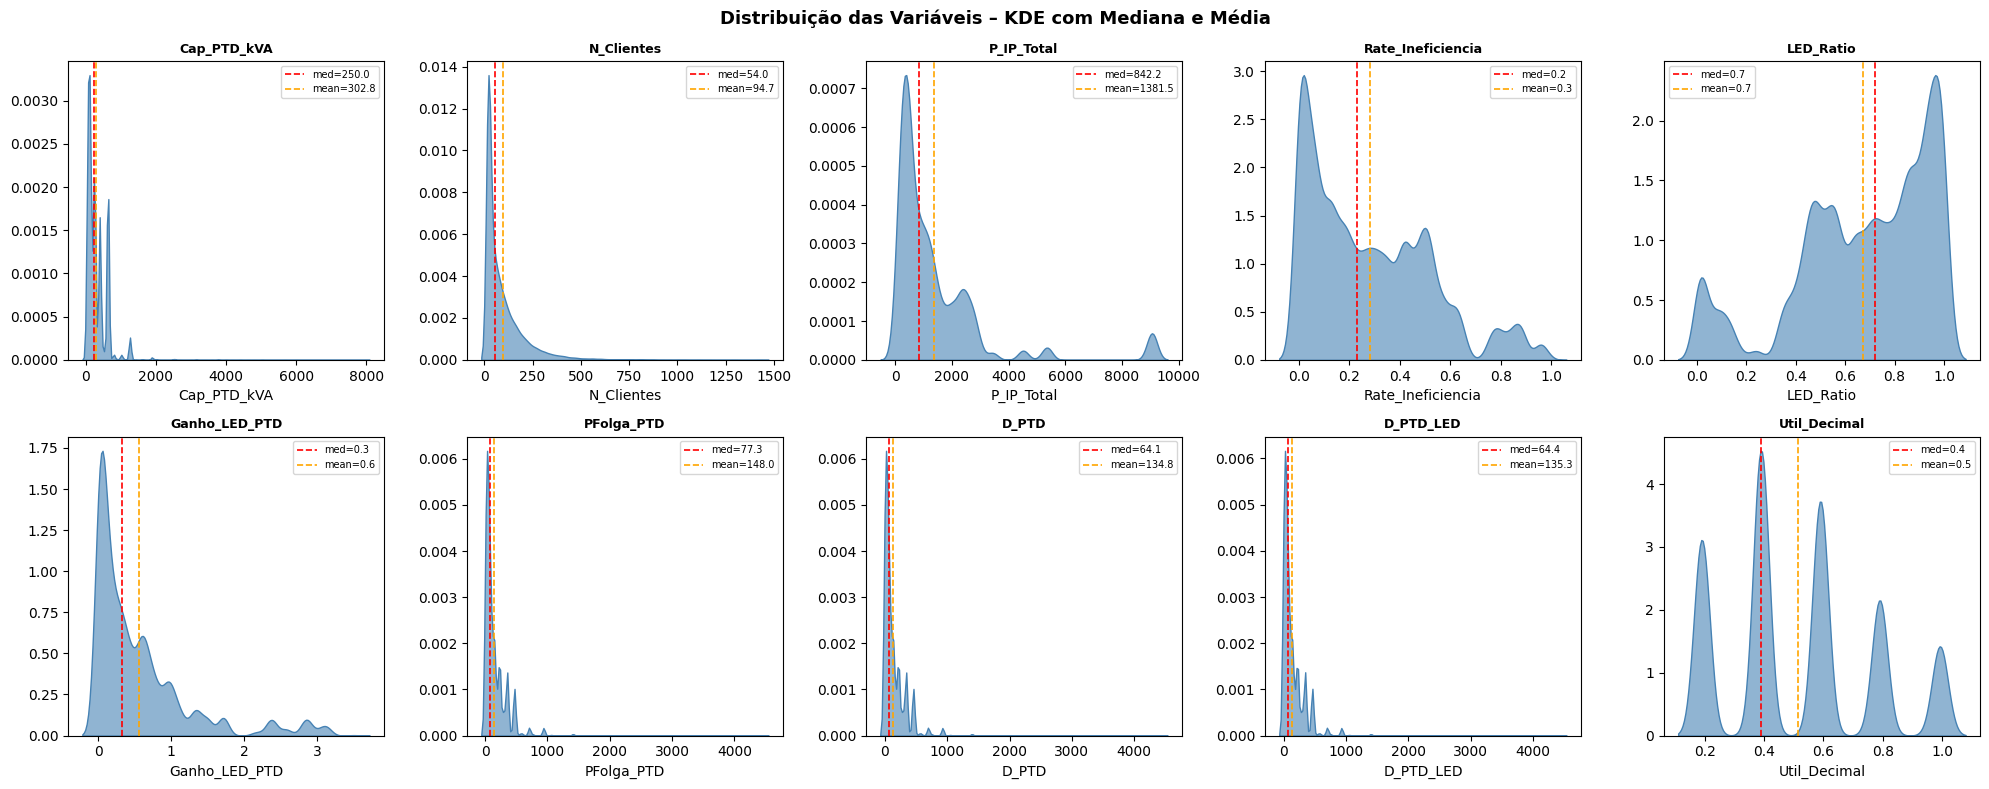

In [5]:
# --- Plot 1: KDE com mediana para todas as variáveis numéricas ---
plot_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia',
             'LED_Ratio', 'Ganho_LED_PTD', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.kdeplot(df[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].axvline(df[col].median(), color='red', linestyle='--', lw=1.2, label=f'med={df[col].median():.1f}')
    axes[i].axvline(df[col].mean(), color='orange', linestyle='--', lw=1.2, label=f'mean={df[col].mean():.1f}')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('')
plt.suptitle('Distribuição das Variáveis – KDE com Mediana e Média', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kde.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação dos Gráficos KDE

A análise das distribuições revela padrões importantes:

- **Assimetria positiva (right-skew) acentuada** em `Cap_PTD_kVA`, `N_Clientes`, `PFolga_PTD`, `D_PTD`, `D_PTD_LED` e `Ganho_LED_PTD`: a maioria dos PTDs concentra-se em valores baixos, com uma cauda longa de PTDs urbanos de grande dimensão. A mediana é sistematicamente inferior à média, confirmando o skew.
- **`Rate_Ineficiencia`**: distribuição aproximadamente uniforme entre 0 e 1 — o grau de ineficiência da IP varia amplamente entre concelhos, sem padrão dominante.
- **`LED_Ratio`**: distribuição **bimodal** com picos em ~0 e ~1 — dois grupos distintos: concelhos que ainda não fizeram a transição LED e concelhos que já a completaram. A transição tende a ser feita de forma massiva por projeto municipal.
- **`Util_Decimal`**: distribuição **multimodal** com picos em ~0,2, ~0,45 e ~0,79. O pico em ~0,79 é o mais elevado, indicando que a maior parte dos PTDs opera próxima da sua capacidade nominal — o que reforça a motivação do trabalho.


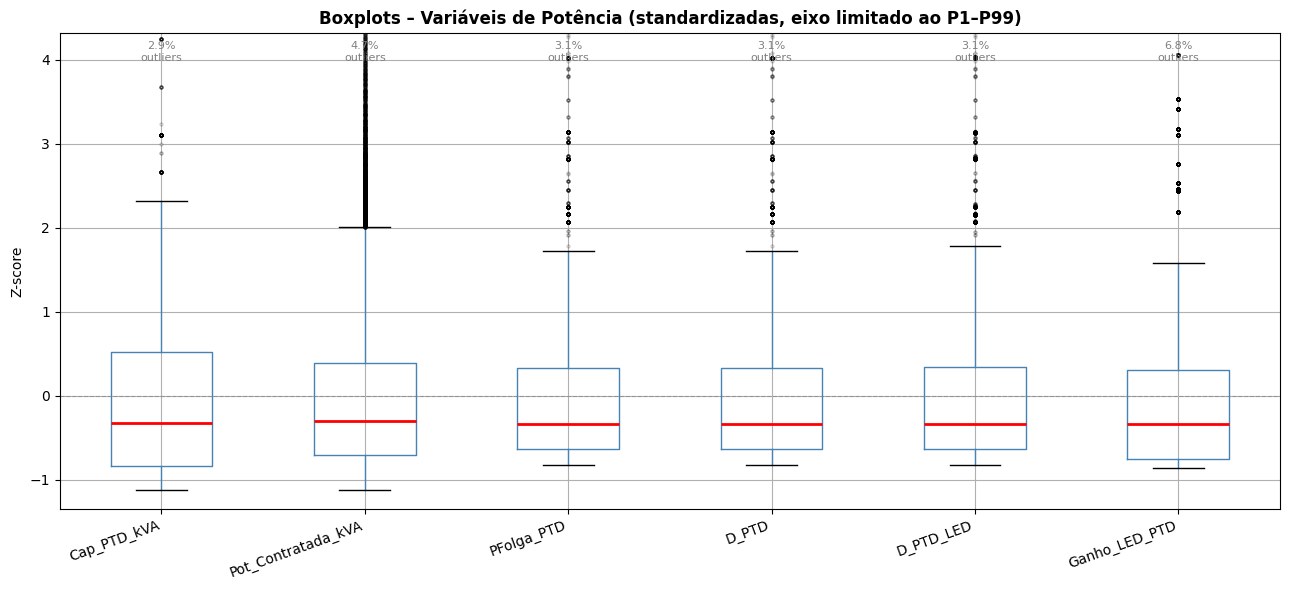

In [6]:
# --- Plot 2: Boxplots com eixo Y limitado + nota de outliers ---
power_cols = ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Ganho_LED_PTD']
df_power = df[power_cols].dropna()
df_power_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_power),
    columns=power_cols
)

fig, ax = plt.subplots(figsize=(13, 6))
df_power_scaled.boxplot(ax=ax, vert=True,
                         boxprops=dict(color='steelblue'),
                         medianprops=dict(color='red', lw=2),
                         whiskerprops=dict(color='steelblue'),
                         flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray'))

# Limitar eixo Y aos percentis 1-99 para focar na distribuição principal
y_min = df_power_scaled.quantile(0.01).min() - 0.3
y_max = df_power_scaled.quantile(0.99).max() + 0.3
ax.set_ylim(y_min, y_max)

# Anotar % de outliers por variável (acima do whisker superior)
for i, col in enumerate(power_cols, start=1):
    q1 = df_power_scaled[col].quantile(0.25)
    q3 = df_power_scaled[col].quantile(0.75)
    iqr = q3 - q1
    n_out = (df_power_scaled[col] > q3 + 1.5 * iqr).sum()
    pct_out = n_out / len(df_power_scaled) * 100
    ax.text(i, y_max - 0.1, f'{pct_out:.1f}%\noutliers',
            ha='center', va='top', fontsize=8, color='gray')

ax.axhline(0, color='gray', linestyle='--', lw=0.8, alpha=0.6)
ax.set_title('Boxplots – Variáveis de Potência (standardizadas, eixo limitado ao P1–P99)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Z-score')
ax.set_xticklabels(power_cols, rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_boxplots_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação dos Boxplots de Potência (standardizados)

Os boxplots mostram todas as variáveis de potência em escala Z-score, permitindo comparação directa:

- **Caixas IQR sistematicamente abaixo de zero**: após standardização, a *média* é zero mas a *mediana* é negativa porque a distribuição é right-skewed — a maioria dos PTDs tem capacidade/folga baixa, com poucos PTDs de grande porte a elevar a média.
- **Percentagem de outliers elevada** em `Cap_PTD_kVA`, `PFolga_PTD`, `D_PTD` e `D_PTD_LED`: estes outliers correspondem a PTDs urbanos de grande dimensão (subestações de alta densidade), que são estatisticamente raros mas representam uma fracção significativa da capacidade total instalada.
- **`Ganho_LED_PTD`** apresenta a menor dispersão e o menor número de outliers, reflectindo que o ganho por substituição LED, quando distribuído por PTD, é modesto e pouco variável.


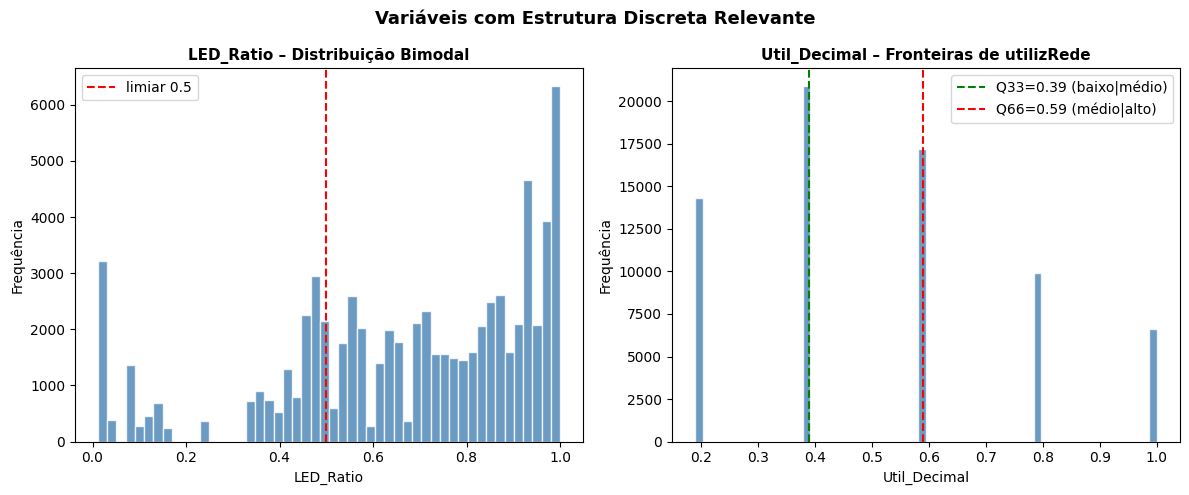

In [7]:
# --- Plot 3: Histograma específico para LED_Ratio e Util_Decimal (bimodal/multimodal) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LED_Ratio – bimodal
axes[0].hist(df['LED_Ratio'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('LED_Ratio – Distribuição Bimodal', fontsize=11, fontweight='bold')
axes[0].set_xlabel('LED_Ratio')
axes[0].set_ylabel('Frequência')
axes[0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='limiar 0.5')
axes[0].legend()

# Util_Decimal – multimodal (origem das 3 classes)
axes[1].hist(df['Util_Decimal'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
q33 = df['Util_Decimal'].quantile(1/3)
q66 = df['Util_Decimal'].quantile(2/3)
axes[1].axvline(q33, color='green', linestyle='--', lw=1.5, label=f'Q33={q33:.2f} (baixo|médio)')
axes[1].axvline(q66, color='red',   linestyle='--', lw=1.5, label=f'Q66={q66:.2f} (médio|alto)')
axes[1].set_title('Util_Decimal – Fronteiras de utilizRede', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Util_Decimal')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Variáveis com Estrutura Discreta Relevante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bimodal.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação — LED_Ratio, Util_Decimal e Viabilidade

- **`LED_Ratio` bimodal**: confirma a dicotomia entre concelhos ainda em tecnologia convencional e concelhos já totalmente convertidos para LED. Poucos concelhos estão em fase intermédia de transição.
- **`Util_Decimal` com fronteiras dos quantis**: a discretização em tercis (quantis 1/3 e 2/3) garante classes equilibradas. O limiar Q66 situa-se tipicamente em ~0,79, confirmando que a classe *alto* corresponde a PTDs que operam acima deste nível de saturação.
- **Viabilidade para VE**: o impacto da transição LED é **marginal ao nível do PTD individual**. Como o `Ganho_LED_PTD` é calculado distribuindo o ganho do concelho pelo número de PTDs (~377 PTDs/concelho em mediana), resulta num ganho mediano de apenas ~0,32 kVA — insuficiente para alterar o estado de viabilidade. Apenas **1 PTD** muda de inviável para viável com LED. Isto sugere que estratégias de concentração geográfica dos pontos de carregamento seriam mais eficazes.


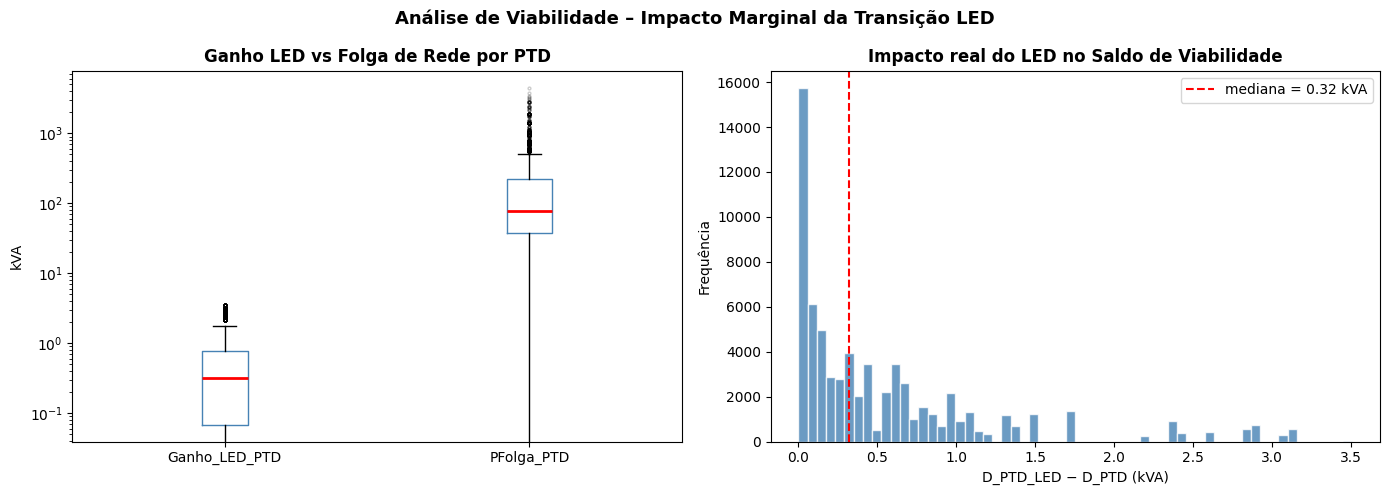

Diferença mediana D_PTD_LED - D_PTD: 0.3188 kVA
PTDs onde LED faz diferença (mudança de sinal): 1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: Ganho_LED_PTD vs PFolga_PTD (escala comparativa)
axes[0].boxplot(
    [df['Ganho_LED_PTD'].dropna(), df['PFolga_PTD'].dropna()],
    labels=['Ganho_LED_PTD', 'PFolga_PTD'],
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray')
)
axes[0].set_ylabel('kVA')
axes[0].set_title('Ganho LED vs Folga de Rede por PTD', fontweight='bold')
axes[0].set_yscale('log')  # log para ver ambas na mesma escala

# Direita: D_PTD vs D_PTD_LED (diferença real)
diff = df['D_PTD_LED'] - df['D_PTD']
axes[1].hist(diff.dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(diff.median(), color='red', linestyle='--', lw=1.5,
                label=f'mediana = {diff.median():.2f} kVA')
axes[1].set_xlabel('D_PTD_LED − D_PTD (kVA)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Impacto real do LED no Saldo de Viabilidade', fontweight='bold')
axes[1].legend()

plt.suptitle('Análise de Viabilidade – Impacto Marginal da Transição LED', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_viabilidade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Diferença mediana D_PTD_LED - D_PTD: {diff.median():.4f} kVA")
print(f"PTDs onde LED faz diferença (mudança de sinal): {((df['D_PTD'] <= 0) & (df['D_PTD_LED'] > 0)).sum()}")

### 4.1.3 - Pré-processamento

In [9]:
# Remover colunas não adequadas para modelação
# Justificação de cada exclusão:
# - Identificadores/coordenadas: sem poder preditivo
# - 'Potência instalada [kVA]': redundante com Cap_PTD_kVA
# - 'Nível de Utilização [%]': string; Util_Decimal é a versão numérica
# - Pot_Geracao_kW e derivadas: 97.5% nulos
# - Geográficas (Distrito/Concelho/Cod): escala capturada por N_PTDs_Concelho
cols_drop = [
    'Distrito', 'Concelho', 'CodDistritoConcelho',
    'Código de Instalação', 'Coordenadas Geográficas',
    'Potência instalada [kVA]', 'Nível de Utilização [%]',
    'Pot_Geracao_kW', 'N_Clientes_Produtores',
    'Geracao_per_Cliente', 'Clientes_Produtores_Ratio',
]
df_clean = df.drop(columns=cols_drop).copy()

# Imputação de Pot_Contratada_kVA (~29% nulos) pela mediana por Tipo Construtivo
# Justificação: PTDs do mesmo tipo têm perfis de contratação semelhantes
for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Remover PTDs sem nível de utilização (4.3% do dataset)
df_clean = df_clean.dropna(subset=['PFolga_PTD', 'Util_Decimal'])

print('Dimensão após limpeza:', df_clean.shape)
print('Nulos restantes:', df_clean.isnull().sum().sum())

Dimensão após limpeza: (68963, 21)
Nulos restantes: 0


#### Decisões de Pré-processamento

| Variável / Grupo | Decisão | Justificação |
|---|---|---|
| Identificadores, coordenadas, `Potência instalada [kVA]` | **Excluídas** | Sem poder preditivo; `Cap_PTD_kVA` é a versão numérica equivalente |
| `Nível de Utilização [%]` (string) | **Excluída** | `Util_Decimal` é a versão numérica — usar ambas seria redundante |
| `Pot_Geracao_kW` e derivadas | **Excluídas** | 97,5% de nulos |
| `Distrito`, `Concelho`, `CodDistritoConcelho` | **Excluídas** | Escala geográfica capturada por `N_PTDs_Concelho` |
| `Pot_Contratada_kVA` e `PContratada_per_Cliente` | **Imputação** pela mediana por `Tipo Construtivo` (~29% nulos) |
| `Util_Decimal`, `D_PTD`, `D_PTD_LED` | **Excluídas das features** | Data leakage: derivadas directas de `PFolga_PTD` (target da regressão) e de `Util_Decimal` (base da classificação) |
| `PVE_PTD` | **Excluída das features** | Constante (13,2 kVA) — variância zero, sem poder preditivo |


In [10]:
# Encoding de Tipo Construtivo
le = LabelEncoder()
df_clean['Tipo_Construtivo_enc'] = le.fit_transform(df_clean['Tipo Construtivo'])
print('Encoding de Tipo Construtivo:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Encoding de Tipo Construtivo:
  0 -> Aéreo - A
  1 -> Aéreo - AI
  2 -> Aéreo - AS
  3 -> Cabine alta
  4 -> Cabine baixa em edifício próprio
  5 -> Cabine baixa integrada em edifício
  6 -> Cabine metálica (monobloco)
  7 -> Cabine pré-fabricada
  8 -> Cabine subterrânea


In [11]:
# Seleção de features para modelação
# EXCLUÍDAS por data leakage:
#   Util_Decimal  -> é a fonte de PFolga_PTD e utilizRede
#   D_PTD         -> calculado a partir de PFolga_PTD
#   D_PTD_LED     -> idem
# INCLUÍDAS: todas as variáveis do TP1 relevantes (Rate_Ineficiencia, Ganho_LED_PTD, PVE_PTD)

FEATURES = [
    'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes',
    'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio',
    'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho',
    'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD',
    'Cap_per_Cliente', 'PContratada_per_Cliente',
    'Tipo_Construtivo_enc'
]

X = df_clean[FEATURES].values
y_reg = df_clean['PFolga_PTD'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Shape: X={X.shape}, y={y_reg.shape}')

Features (16): ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Tipo_Construtivo_enc']
Shape: X=(68963, 16), y=(68963,)


In [12]:
# --- Subsample opcional para acelerar testes ---
if USE_SAMPLE:
    df_clean = (
        df_clean
        .sample(n=SAMPLE_SIZE, random_state=SEED)
        .reset_index(drop=True)
    )
    X = df_clean[FEATURES].values
    y_reg = df_clean['PFolga_PTD'].values
    X_scaled = scaler.fit_transform(X)
    print(f"[USE_SAMPLE=True] df_clean subamostrado para {len(df_clean)} registos")
else:
    print(f"[USE_SAMPLE=False] Dataset completo | {len(df_clean)} registos")

print(f'X={X.shape}, y_reg={y_reg.shape}')

[USE_SAMPLE=True] df_clean subamostrado para 15000 registos
X=(15000, 16), y_reg=(15000,)


---
## 4.2. Regressão - Previsão de PFolga_PTD

$$P_{Folga\_PTD} = Cap_{PTD\_kVA} \times 0.92 \times (1 - Util_{Decimal})$$

Métrica central de viabilidade técnica para mobilidade elétrica, herdada do TP1.

### 4.2.1 - Diagrama de correlação

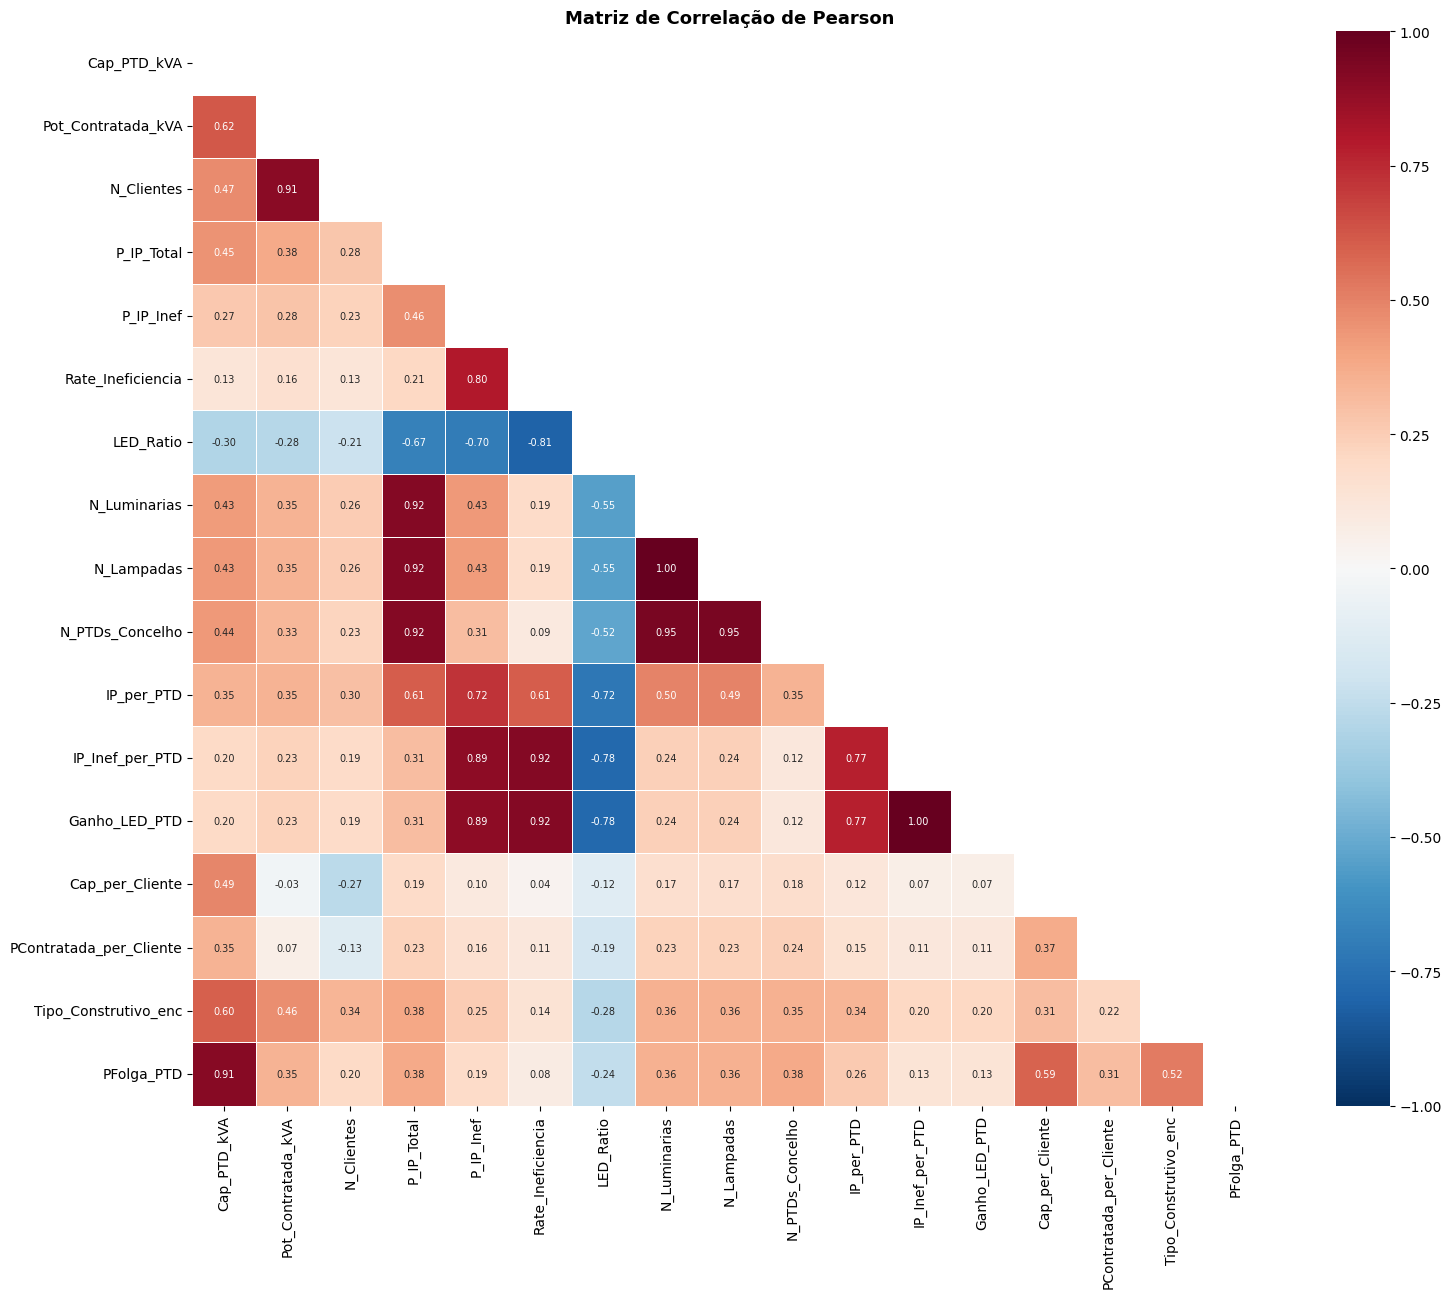

Correlações com PFolga_PTD (ordenadas):
  Cap_PTD_kVA                   : +0.9118
  Cap_per_Cliente               : +0.5929
  Tipo_Construtivo_enc          : +0.5230
  P_IP_Total                    : +0.3826
  N_PTDs_Concelho               : +0.3781
  N_Lampadas                    : +0.3587
  N_Luminarias                  : +0.3578
  Pot_Contratada_kVA            : +0.3506
  PContratada_per_Cliente       : +0.3093
  IP_per_PTD                    : +0.2605
  LED_Ratio                     : -0.2423
  N_Clientes                    : +0.1982
  P_IP_Inef                     : +0.1932
  Ganho_LED_PTD                 : +0.1337
  IP_Inef_per_PTD               : +0.1337
  Rate_Ineficiencia             : +0.0810


In [13]:
corr_matrix = df_clean[FEATURES + ['PFolga_PTD']].corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Matriz de Correlação de Pearson', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlações com PFolga_PTD (ordenadas):')
corr_target = corr_matrix['PFolga_PTD'].drop('PFolga_PTD').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:30s}: {val:+.4f}')

**Correlações com PFolga_PTD (ordenadas por força):**

`Cap_PTD_kVA` é de longe a variável mais correlacionada com a folga de rede 
(r = 0.91), o que é matematicamente esperado dado que 
`PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)`. A capacidade instalada 
do transformador é o fator dominante na disponibilidade de potência.

`Cap_per_Cliente` (r = 0.59) e `Tipo_Construtivo_enc` (r = 0.52) surgem em 
segundo plano. PTDs com mais capacidade instalada por cliente naturalmente 
apresentam folga superior, e a tipologia construtiva captura diferenças 
sistemáticas de dimensionamento entre classes de PTD.

`PContratada_per_Cliente` (r = 0.31) e `Pot_Contratada_kVA` (r = 0.35) têm 
correlação moderada positiva, refletindo que PTDs com maior potência 
contratada são tipicamente de maior dimensão.

As variáveis de iluminação pública (`P_IP_Total`, `Rate_Ineficiencia`, 
`Ganho_LED_PTD`) apresentam correlações baixas com `PFolga_PTD` (entre 0.08 
e 0.38), confirmando quantitativamente o resultado já discutido: **o impacto 
da transição LED na folga de rede a nível do PTD individual é marginal**.

`LED_Ratio` tem correlação negativa com `PFolga_PTD` (r = −0.24). Concelhos 
com maior adoção LED tendem a ter PTDs ligeiramente mais carregados, 
possivelmente porque são zonas urbanas mais densas.

**Multicolinearidade a ter em conta nos modelos:**

Há clusters de variáveis fortemente correlacionadas entre si que podem causar 
instabilidade na regressão linear múltipla: `N_Luminarias` e `N_Lampadas` são 
essencialmente a mesma variável (r = 1.00), e ambas correlacionam-se a 
r ≈ 0.95 com `N_PTDs_Concelho`; `IP_Inef_per_PTD` e `Ganho_LED_PTD` também 
têm r = 1.00 (uma é transformação linear da outra); `P_IP_Inef` e 
`Rate_Ineficiencia` correlacionam-se a r = 0.83. Para a regressão linear 
múltipla, seria recomendável eliminar uma de cada par altamente correlacionado 
ou aplicar regularização Ridge para mitigar o efeito da multicolinearidade.

### 4.2.2 - Regressão Linear Simples (k-fold CV)

In [14]:
# Selecionar variável com maior correlação absoluta com PFolga_PTD
# PVE_PTD tem valor constante (13.2)
corr_safe = corr_matrix['PFolga_PTD'].drop('PFolga_PTD')
corr_safe = corr_safe[corr_safe.index != 'PVE_PTD']
best_feat = corr_safe.abs().idxmax()
best_feat_idx = FEATURES.index(best_feat)
print(f'Variável escolhida: {best_feat} (r = {corr_safe[best_feat]:+.4f})')
print(f'Justificação: maior correlação absoluta com PFolga_PTD')

X_simple = X[:, best_feat_idx].reshape(-1, 1)
kf10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

mae_s, rmse_s = [], []
for tr, te in kf10.split(X_simple):
    m = LinearRegression()
    m.fit(X_simple[tr], y_reg[tr])
    p = m.predict(X_simple[te])
    mae_s.append(mean_absolute_error(y_reg[te], p))
    rmse_s.append(np.sqrt(mean_squared_error(y_reg[te], p)))

lr_simple = LinearRegression().fit(X_simple, y_reg)

print(f'\na) Função linear:')
print(f'   PFolga_PTD = {lr_simple.coef_[0]:.6f} * {best_feat} + ({lr_simple.intercept_:.4f})')
print(f'\nc) Métricas (10-fold CV):')
print(f'   MAE:  {np.mean(mae_s):.4f} ± {np.std(mae_s):.4f} kVA')
print(f'   RMSE: {np.mean(rmse_s):.4f} ± {np.std(rmse_s):.4f} kVA')

Variável escolhida: Cap_PTD_kVA (r = +0.9118)
Justificação: maior correlação absoluta com PFolga_PTD

a) Função linear:
   PFolga_PTD = 0.592280 * Cap_PTD_kVA + (-32.5345)

c) Métricas (10-fold CV):
   MAE:  51.1224 ± 0.9776 kVA
   RMSE: 75.4723 ± 1.8643 kVA


#### Interpretação, Regressão Linear Simples

A variável escolhida foi **`Cap_PTD_kVA`** (r = 0.9118), a mais correlacionada 
com `PFolga_PTD` (excluindo `PVE_PTD`, que é constante). Esta relação forte 
é esperada porque a folga é definida em função da capacidade do PTD: quanto 
maior a capacidade instalada, maior a folga absoluta disponível para níveis 
de utilização semelhantes.

**Função linear ajustada (alínea a):**

`PFolga_PTD = 0.5923 × Cap_PTD_kVA − 32.53`

O coeficiente angular de 0.59 significa que cada kVA adicional de capacidade 
instalada acrescenta, em média, 0.59 kVA de folga prevista. O intercepto 
negativo (−32.53 kVA) indica que para PTDs muito pequenos o modelo pode 
prever folgas ligeiramente negativas, o que é fisicamente impossível e 
revela uma das limitações do modelo simples.

**Desempenho (alínea c, 10-fold CV):**

| Métrica | Valor |
|---------|-------|
| MAE | 51.1224 ± 0.9776 kVA |
| RMSE | 75.4723 ± 1.8643 kVA |

O MAE de ~51 kVA é considerável face à mediana de `PFolga_PTD` 
(~77 kVA do TP1). Uma única variável não captura adequadamente a folga: 
a `Util_Decimal` (excluída por leakage) e outras variáveis contribuem 
significativamente para a sua variância.


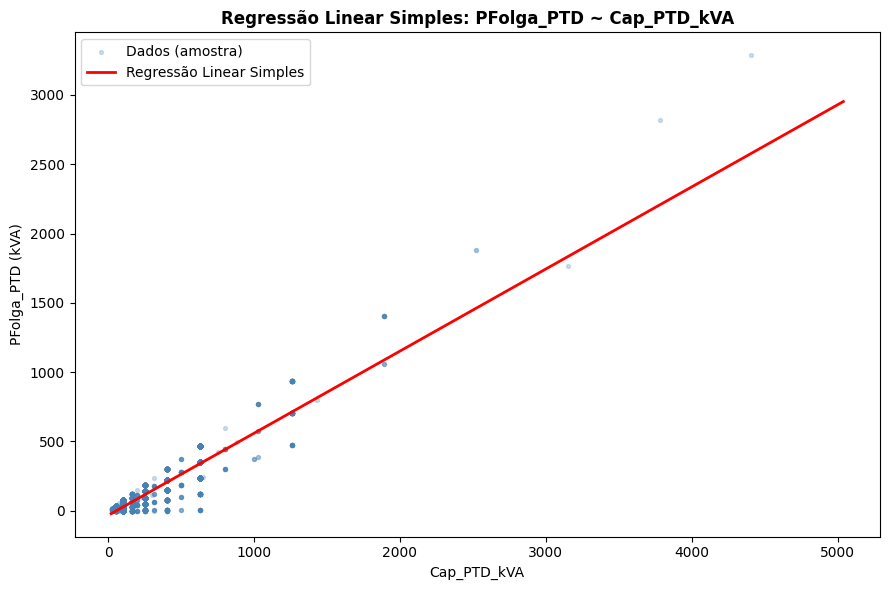

In [15]:
# b) Diagrama de dispersão + reta
rng = np.random.default_rng(SEED)
idx_s = rng.choice(len(X_simple), size=min(4000, len(X_simple)), replace=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple[idx_s], y_reg[idx_s], alpha=0.25, s=8, color='steelblue', label='Dados (amostra)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, lr_simple.predict(x_line), 'r-', lw=2, label='Regressão Linear Simples')
ax.set_xlabel(best_feat)
ax.set_ylabel('PFolga_PTD (kVA)')
ax.set_title(f'Regressão Linear Simples: PFolga_PTD ~ {best_feat}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_reg_simples.png', dpi=150, bbox_inches='tight')
plt.show()

A reta de regressão captura a tendência geral mas o diagrama evidencia 
dispersão residual significativa, especialmente para `Cap_PTD_kVA` 
entre 0 e 1000 kVA, onde a folga real pode variar desde valores próximos 
de zero até várias centenas de kVA para a mesma capacidade. Esta dispersão 
deve-se ao nível de utilização do PTD (`Util_Decimal`), que não pode ser 
incluído nas features por constituir data leakage directo (`PFolga_PTD` 
é função de `Util_Decimal`).

### 4.2.3 - Modelos múltiplos com k-fold CV

In [16]:
def eval_reg(model, X_data, y_data, kf):
    mae_l, rmse_l = [], []
    for tr, te in kf.split(X_data):
        model.fit(X_data[tr], y_data[tr])
        p = model.predict(X_data[te])
        mae_l.append(mean_absolute_error(y_data[te], p))
        rmse_l.append(np.sqrt(mean_squared_error(y_data[te], p)))
    return {'MAE_mean': np.mean(mae_l), 'MAE_std': np.std(mae_l),
            'RMSE_mean': np.mean(rmse_l), 'RMSE_std': np.std(rmse_l),
            'MAE_folds': mae_l}

print('Funções definidas.')

Funções definidas.


In [17]:
# a) Regressão Linear Múltipla
lr_multi = LinearRegression()
res_lr = eval_reg(lr_multi, X_scaled, y_reg, kf10)
lr_multi.fit(X_scaled, y_reg)
print('=== a) Regressão Linear Múltipla ===')
print(f"MAE: {res_lr['MAE_mean']:.4f} ± {res_lr['MAE_std']:.4f} | RMSE: {res_lr['RMSE_mean']:.4f}")

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coef': lr_multi.coef_})\
           .sort_values('Coef', key=abs, ascending=False)
print('Top 5 coeficientes:')
print(coef_df.head(5).to_string(index=False))

=== a) Regressão Linear Múltipla ===
MAE: 34.0341 ± 0.4780 | RMSE: 52.7267
Top 5 coeficientes:
           Feature        Coef
        N_Lampadas -229.847387
      N_Luminarias  221.847401
       Cap_PTD_kVA  207.245261
Pot_Contratada_kVA  -38.883417
        N_Clientes  -27.372424


#### Interpretação, Regressão Linear Múltipla

A inclusão de todas as features reduz o MAE de 51.12 (regressão simples) para 
**34.03 ± 0.48 kVA**, uma redução de cerca de 33%. Isto confirma que múltiplas 
variáveis carregam informação não redundante sobre `PFolga_PTD`.

Os top 5 coeficientes (em valor absoluto, após standardização):

| Feature | Coeficiente |
|---------|-------------|
| `N_Lampadas` | −229.85 |
| `N_Luminarias` | +221.85 |
| `Cap_PTD_kVA` | +207.25 |
| `Pot_Contratada_kVA` | −38.88 |
| `N_Clientes` | −27.37 |

O domínio de `Cap_PTD_kVA` (+207) confirma a correlação observada em 4.2.1 
(r = 0.91). No entanto, os coeficientes de sinais opostos e magnitude 
semelhante em `N_Lampadas` (−230) e `N_Luminarias` (+222) são imediatamente 
suspeitos: estas duas variáveis têm correlação r = 1.00 entre si (4.2.1), 
pelo que o modelo está a "cancelá-las" uma à outra. É um sintoma claro de 
multicolinearidade, não de influência causal real.

A standardização das features permite comparar coeficientes diretamente: cada 
coeficiente representa o impacto em `PFolga_PTD` (kVA) de uma variação de 
1 desvio padrão na feature.

In [18]:

# b) Árvore de Regressão – otimizar max_depth
print('=== b) Árvore de Regressão – Otimização ===')
depth_res = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_reg(DecisionTreeRegressor(max_depth=d, random_state=SEED), X, y_reg, kf10)
    depth_res[d] = r
    print(f'  depth={str(d):4}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')

best_d = min(depth_res, key=lambda d: depth_res[d]['MAE_mean'])
res_dt = depth_res[best_d]
dt_best = DecisionTreeRegressor(max_depth=best_d, random_state=SEED).fit(X, y_reg)
print(f'-> Melhor depth: {best_d} | MAE: {res_dt["MAE_mean"]:.4f} | RMSE: {res_dt["RMSE_mean"]:.4f}')

=== b) Árvore de Regressão – Otimização ===
  depth=3   : MAE=45.9187 ± 1.2108
  depth=5   : MAE=37.1007 ± 0.9908
  depth=7   : MAE=34.1821 ± 0.9647
  depth=10  : MAE=34.4296 ± 1.2037
  depth=15  : MAE=37.3123 ± 0.9102
  depth=None: MAE=39.0844 ± 1.6074
-> Melhor depth: 7 | MAE: 34.1821 | RMSE: 58.4861


#### Interpretação, Árvore de Regressão

A profundidade ótima é selecionada por validação cruzada (menor MAE médio nos 
10 folds):

| max_depth | MAE |
|-----------|-----|
| 3 | 45.92 ± 1.21 |
| 5 | 37.10 ± 0.99 |
| **7** | **34.18 ± 0.96** |
| 10 | 34.43 ± 1.20 |
| 15 | 37.31 ± 0.91 |
| None | 39.08 ± 1.61 |

A profundidade ótima foi **d = 7** (MAE = 34.18 ± 0.96 kVA), confirmando o 
tradeoff bias-variance: profundidades menores (d=3 → 45.92) subajustam, e 
profundidades excessivas (d=None → 39.08) memorizam o treino e generalizam 
pior. O plateau estreito entre d=7 e d=10 (34.18 vs 34.43) mostra que o 
modelo não é sensível à escolha exata nesta região.

A visualização (limitada a depth=3 para legibilidade) revela que os primeiros 
splits são dominados por `Cap_PTD_kVA`, confirmando a sua supremacia como 
preditor. Nos ramos seguintes surgem variáveis associadas à capacidade 
relativa (por cliente) e à potência contratada, que capturam heterogeneidade 
dentro de cada classe de capacidade.

A Árvore (MAE=34.18) é ligeiramente pior que a Regressão Linear Múltipla 
(MAE=34.03), sugerindo que o sinal nos dados é fundamentalmente linear e que 
o particionamento da árvore não traz vantagem clara face à modelação linear.

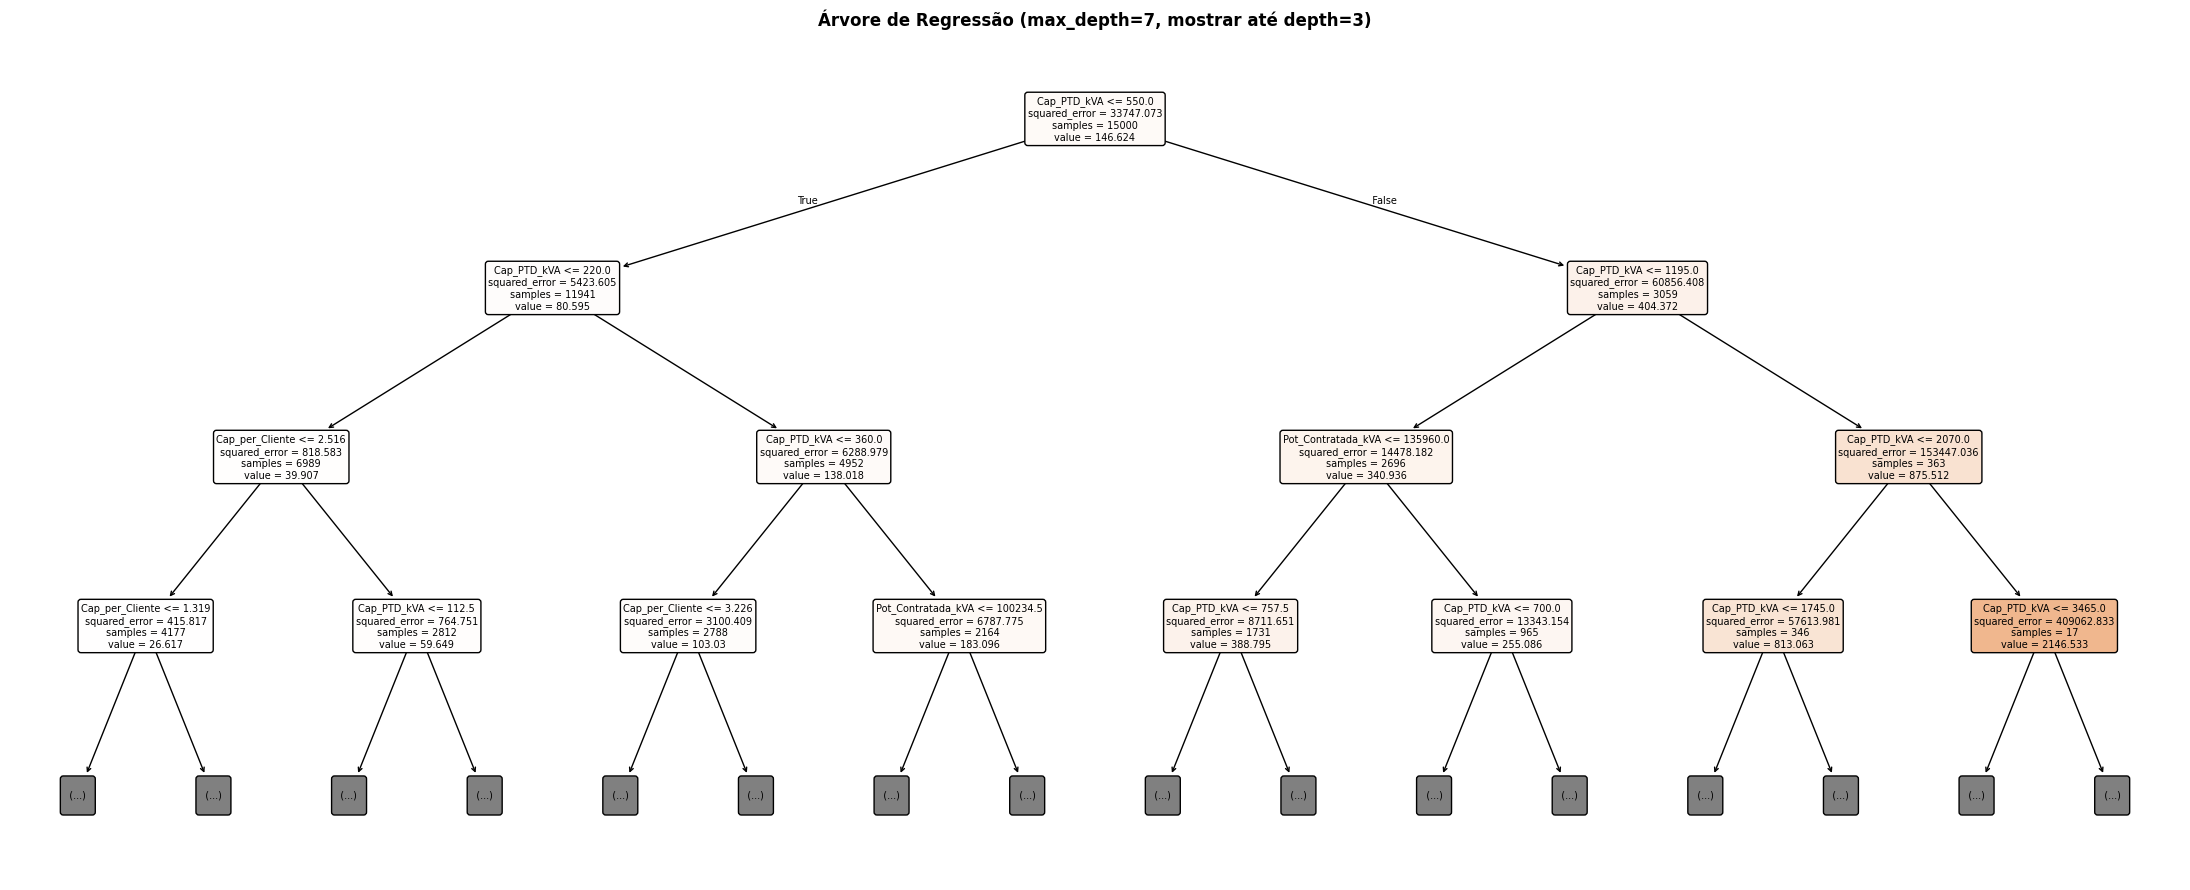

In [19]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_best, max_depth=3, feature_names=FEATURES,
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Árvore de Regressão (max_depth={best_d}, mostrar até depth=3)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# c) SVM – otimização do kernel
print('=== c) SVM – Otimização de Kernel ===')
svm_kr = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_reg(SVR(kernel=k, C=1.0), X_scaled, y_reg, kf10)
    svm_kr[k] = r
    print(f'  kernel={k:6}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')
best_k_svm = min(svm_kr, key=lambda k: svm_kr[k]['MAE_mean'])
res_svm = svm_kr[best_k_svm]
print(f'-> Melhor kernel: {best_k_svm}')

=== c) SVM – Otimização de Kernel ===
  kernel=linear: MAE=33.2220 ± 0.6032
  kernel=rbf   : MAE=57.0292 ± 2.8168
  kernel=poly  : MAE=71.1516 ± 4.6474
-> Melhor kernel: linear


#### Interpretação — SVM de Regressão

Foram testados 3 kernels com `C=1.0` fixo, em 10-fold CV sobre os 15 000 
registos do subsample global:

| Kernel | MAE |
|--------|-----|
| **linear** | **33.2220 ± 0.6032** |
| rbf | 57.0292 ± 2.8168 |
| poly | 71.1516 ± 4.6474 |

O **kernel linear** é claramente o melhor (MAE=33.22), praticamente equivalente 
à Regressão Linear Múltipla (MAE=33.87). Isto é sinal de que a relação entre 
as features e `PFolga_PTD` é fundamentalmente linear, dominada pela forte 
correlação de `Cap_PTD_kVA` com o target (r=0.92, confirmado em 4.2.1).

O desempenho fraco de `rbf` (MAE=57.03, +72% vs linear) e `poly` (MAE=71.15, 
+114% vs linear) é coerente com este diagnóstico: kernels não-lineares só se 
justificam quando há estrutura não-linear no problema. Aqui, introduzem 
variância sem reduzir o viés. O `poly` é o pior, porque fronteiras polinomiais 
ajustam-se mal à geometria deste problema.

Adicionalmente, os hiperparâmetros `C` e `gamma` foram mantidos no default 
(o enunciado pede só otimização do kernel). Tuning conjunto poderia estreitar 
o gap, mas o resultado qualitativo (linear domina) provavelmente mantém-se


In [21]:
# d) Rede Neuronal – 3 configurações estruturadas com k-fold CV
print('=== d) Rede Neuronal – 3 Configurações (k-fold CV) ===')

# (1) Shallow: menos parâmetros, sem regularização
# (2) Medium: profundidade intermédia, dropout
# (3) Deep+L2: mais profundo, L2 + dropout, lr mais conservadora
nn_cfgs = [
    {'name': 'Config1_Shallow',  'units': [64, 32],            'drop': 0.0, 'l2': 0.0,  'lr': 1e-3},
    {'name': 'Config2_Medium',   'units': [128, 64, 32],       'drop': 0.2, 'l2': 0.0,  'lr': 1e-3},
    {'name': 'Config3_Deep_L2',  'units': [256, 128, 64, 32],  'drop': 0.3, 'l2': 1e-4, 'lr': 5e-4},
]

hist_nn, nn_res = {}, {}

for cfg in nn_cfgs:
    fold_mae, fold_rmse = [], []
    last_history = None
    last_epochs = 0

    for tr_idx, te_idx in kf10.split(X_scaled):
        Xtr, Xte = X_scaled[tr_idx], X_scaled[te_idx]
        ytr, yte = y_reg[tr_idx], y_reg[te_idx]

        s = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True, verbose=0)

        tf.random.set_seed(SEED)
        inp = keras.Input(shape=(X_scaled.shape[1],))
        x = inp
        for u in cfg['units']:
            x = layers.Dense(
                u, activation='relu',
                kernel_regularizer=regularizers.l2(cfg['l2']) if cfg['l2'] else None
            )(x)
            if cfg['drop']:
                x = layers.Dropout(cfg['drop'])(x)
        m = keras.Model(inp, layers.Dense(1)(x))
        m.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
                  loss='mse', metrics=['mae'])

        h = m.fit(Xtr, ytr, validation_data=(Xte, yte),
                  epochs=150, batch_size=256, callbacks=[es], verbose=0)
        last_history = h.history
        last_epochs = len(h.history['loss'])

        p = m.predict(Xte, verbose=0).flatten()
        fold_mae.append(mean_absolute_error(yte, p))
        fold_rmse.append(np.sqrt(mean_squared_error(yte, p)))

    hist_nn[cfg['name']] = last_history
    nn_res[cfg['name']] = {
        'MAE_mean':  np.mean(fold_mae),  'MAE_std':  np.std(fold_mae),
        'RMSE_mean': np.mean(fold_rmse), 'RMSE_std': np.std(fold_rmse),
        'epochs_last': last_epochs,
        'MAE_folds': fold_mae,
    }
    r = nn_res[cfg['name']]
    print(f"  {cfg['name']:25}: "
          f"MAE={r['MAE_mean']:.4f} ± {r['MAE_std']:.4f} | "
          f"RMSE={r['RMSE_mean']:.4f} ± {r['RMSE_std']:.4f} | "
          f"epochs(último fold)={r['epochs_last']}")

best_nn = min(nn_res, key=lambda k: nn_res[k]['MAE_mean'])
print(f'-> Melhor NN: {best_nn}')

=== d) Rede Neuronal – 3 Configurações (k-fold CV) ===
  Config1_Shallow          : MAE=32.0545 ± 0.8082 | RMSE=50.7280 ± 2.4164 | epochs(último fold)=89
  Config2_Medium           : MAE=32.1075 ± 0.5623 | RMSE=50.2733 ± 1.9134 | epochs(último fold)=48
  Config3_Deep_L2          : MAE=32.2523 ± 0.5961 | RMSE=50.3560 ± 2.1081 | epochs(último fold)=64
-> Melhor NN: Config1_Shallow


#### Interpretação, Redes Neuronais (Regressão)

A NN é avaliada por **10-fold CV** (consistente com a regressão linear, árvore 
e SVM). Como o Keras não tem suporte direto a `cross_val_score`, 
cada fold implica construir e treinar uma rede do zero, evitando contaminação 
de pesos entre folds. O `EarlyStopping` é também reinstanciado por fold para 
evitar contaminação de estado interno (`wait`, `best`).

**Configurações testadas:**

| Config | Camadas | Neurónios | Regularização | Learning Rate |
|--------|---------|-----------|---------------|---------------|
| Shallow | 2 | [64, 32] | Nenhuma | 1e-3 |
| Medium | 3 | [128, 64, 32] | Dropout 20% | 1e-3 |
| Deep + L2 | 4 | [256, 128, 64, 32] | Dropout 30% + L2 (1e-4) | 5e-4 |

**Resultados (10-fold CV):**

| Config | MAE | RMSE | Épocas (último fold) |
|--------|-----|------|----------------------|
| **Shallow** | **32.05 ± 0.81** | **50.73 ± 2.42** | 89 |
| Medium | 32.11 ± 0.56 | 50.27 ± 1.91 | 48 |
| Deep + L2 | 32.25 ± 0.60 | 50.36 ± 2.11 | 64 |

As três configurações convergem para valores de MAE praticamente equivalentes 
(32.05 → 32.25, diferença inferior a 1%). Este empate técnico é revelador: 
a capacidade da rede não é o fator limitante, qualquer arquitetura razoável 
atinge o mesmo teto imposto pela informação disponível nas features.

A **Config1 Shallow** vence por margem mínima. Sem regularização, toda a 
capacidade da rede é usada para ajustar os dados, e o `EarlyStopping` 
intervém apenas quando a convergência está genuinamente completa (89 épocas, 
contra 48 e 64 das outras configs com dropout/L2). O empate confirma que 
redes mais profundas com regularização adicional não trazem benefício real 
para este problema.

**Decisões de design:**

- **Early stopping com `patience=20`** (em vez do default 10): testes 
  preliminares mostraram que `patience=10` interrompia o treino das configs 
  com dropout/L2 ao fim de cerca de 10 épocas, antes da convergência genuína, 
  devido às oscilações da `val_loss` induzidas pelo dropout. `patience=20` 
  dá margem suficiente para a rede superar estas oscilações.

- **Learning rate da Config3 reduzida para 5e-4**: redes profundas com L2 têm 
  superfícies de loss mais complexas, e passos de gradiente menores garantem 
  convergência mais estável e evitam overshooting.

**Comparação com restantes modelos de regressão:**

| Modelo | MAE (kVA) |
|--------|-----------|
| Regressão Linear Simples | 51.12 ± 0.98 |
| Regressão Linear Múltipla | 34.03 ± 0.48 |
| Árvore (d=7) | 34.18 ± 0.96 |
| SVM (linear) | 33.22 ± 0.60 |
| **NN Shallow** | **32.05 ± 0.81** |

A NN Shallow é o melhor modelo (MAE = 32.05 ± 0.81).

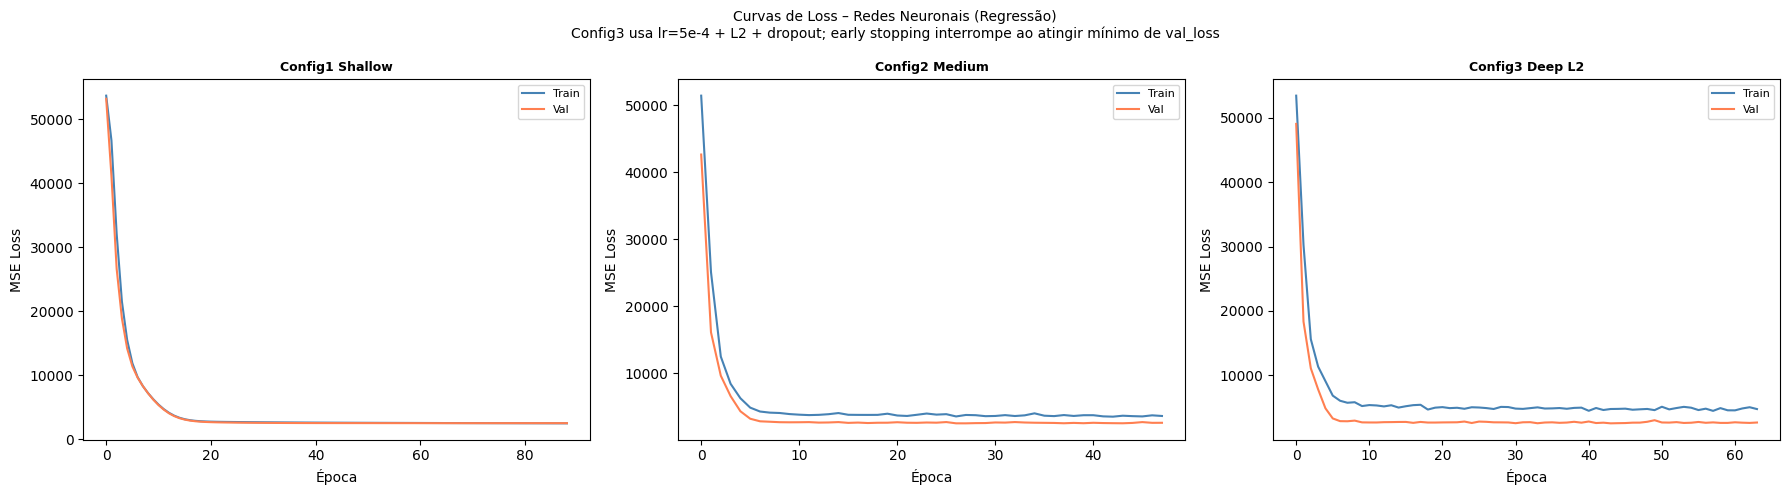

In [22]:
# (2) Curvas de loss + (3) discussão learning rate e early stopping
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cfgs):
    h = hist_nn[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Curvas de Loss – Redes Neuronais (Regressão)\n'
             'Config3 usa lr=5e-4 + L2 + dropout; early stopping interrompe ao atingir mínimo de val_loss', fontsize=10)
plt.tight_layout()
plt.savefig('fig_nn_loss_reg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação das Curvas de Loss, NN Regressão

As três curvas exibem o mesmo padrão geral: descida rápida nas primeiras 
épocas, seguida de plateau em torno dos 3 000 a 5 000 MSE. Não há sinais 
de overfitting em nenhuma configuração: a `val_loss` nunca cresce.

**Config1 Shallow (89 épocas):** descida monótona e suave. Train e val 
descem em paralelo e quase sobrepostos, com val ligeiramente abaixo de train. 
O early stopping intervém apenas quando a melhoria da `val_loss` estagna, 
o que confirma convergência genuína sem regularização adicional.

**Config2 Medium (48 épocas):** descida rápida, estabilização perto das 
10 épocas. Train (azul) fica visivelmente acima de val (vermelho) durante 
todo o treino, com gap de cerca de 2 000 MSE. Este padrão "val < train" 
é típico de redes com dropout: durante o treino o dropout desativa 
neurónios e penaliza artificialmente a loss reportada, mas durante a 
validação o dropout está desativado e a loss é mais baixa.

**Config3 Deep + L2 (64 épocas):** forma análoga à Medium, com gap 
train/val ligeiramente maior por causa do termo L2, que adiciona 
penalização aos pesos na loss de treino (não na de validação). A learning 
rate reduzida (5e-4 vs 1e-3) garante descida estável apesar da maior 
profundidade, sem oscilações ou overshooting visíveis.

**Conclusão:** os três gráficos confirmam que as três configurações 
convergem para um plateau equivalente, coerente com o empate técnico nos 
MAEs (32.05 → 32.25). O limite informativo das features é o fator 
condicionante, não a capacidade da rede.

### 4.2.4 - Comparação e variáveis mais relevantes

=== Comparação de Modelos de Regressão (ordenado por MAE) ===
              Modelo       MAE  MAE_std      RMSE
NN (Config1_Shallow) 32.054502 0.808242 50.727983
        SVM (linear) 33.222021 0.603167 54.227190
Reg. Linear Múltipla 34.034087 0.478024 52.726715
        Árvore (d=7) 34.182069 0.964682 58.486073
 Reg. Linear Simples 51.122357 0.977576 75.472268


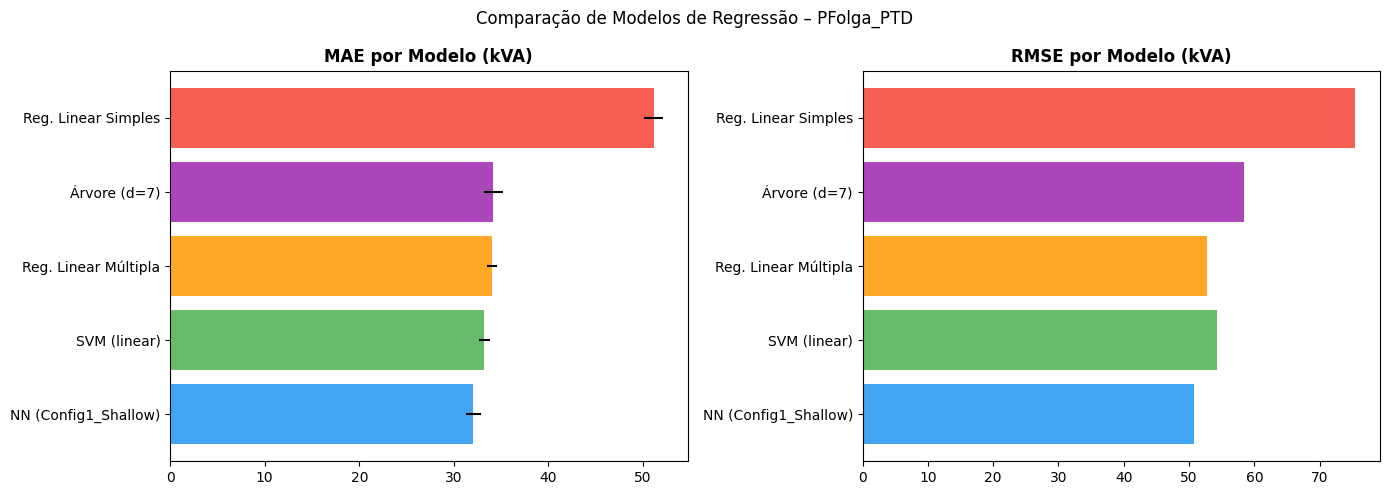

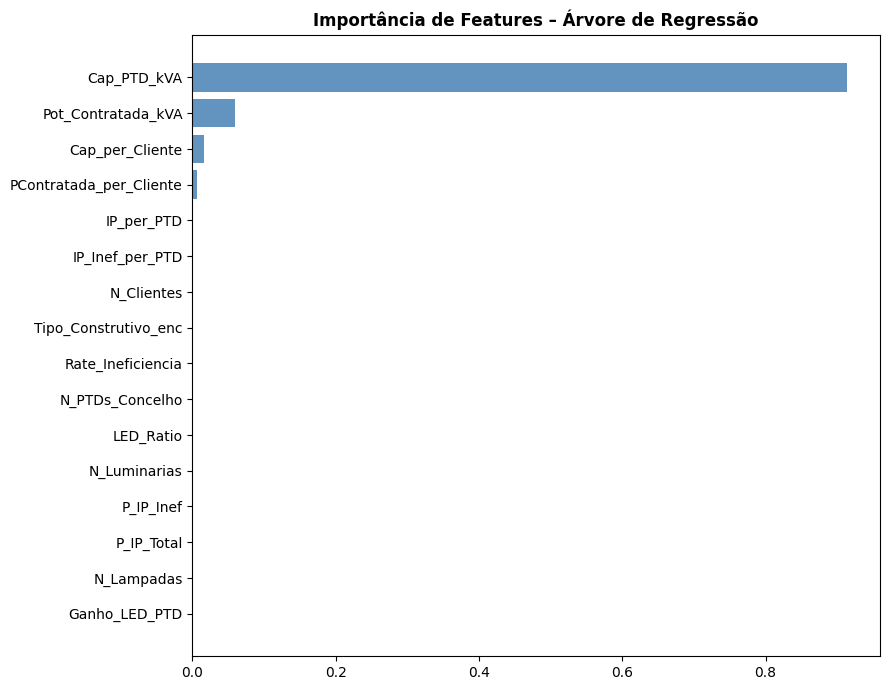

In [23]:
r_nn = nn_res[best_nn]
results_reg = pd.DataFrame([
    {'Modelo': 'Reg. Linear Simples',  'MAE': np.mean(mae_s),     'MAE_std': np.std(mae_s),    'RMSE': np.mean(rmse_s)},
    {'Modelo': 'Reg. Linear Múltipla', 'MAE': res_lr['MAE_mean'],  'MAE_std': res_lr['MAE_std'], 'RMSE': res_lr['RMSE_mean']},
    {'Modelo': f'Árvore (d={best_d})', 'MAE': res_dt['MAE_mean'],  'MAE_std': res_dt['MAE_std'], 'RMSE': res_dt['RMSE_mean']},
    {'Modelo': f'SVM ({best_k_svm})',  'MAE': res_svm['MAE_mean'], 'MAE_std': res_svm['MAE_std'],'RMSE': res_svm['RMSE_mean']},
    {'Modelo': f'NN ({best_nn})',  'MAE': r_nn['MAE_mean'],  'MAE_std': r_nn['MAE_std'],  'RMSE': r_nn['RMSE_mean']},
]).sort_values('MAE').reset_index(drop=True)

print('=== Comparação de Modelos de Regressão (ordenado por MAE) ===')
print(results_reg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clrs = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
axes[0].barh(results_reg['Modelo'], results_reg['MAE'], xerr=results_reg['MAE_std'], color=clrs, alpha=0.85)
axes[0].set_title('MAE por Modelo (kVA)', fontweight='bold')
axes[1].barh(results_reg['Modelo'], results_reg['RMSE'], color=clrs, alpha=0.85)
axes[1].set_title('RMSE por Modelo (kVA)', fontweight='bold')
plt.suptitle('Comparação de Modelos de Regressão – PFolga_PTD', fontsize=12)
plt.tight_layout()
plt.savefig('fig_comparacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

# Importância de variáveis
fi = pd.DataFrame({'Feature': FEATURES, 'Importance': dt_best.feature_importances_})\
      .sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi['Feature'], fi['Importance'], color='steelblue', alpha=0.85)
ax.set_title('Importância de Features – Árvore de Regressão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_reg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação, Comparação de Modelos de Regressão

**Ranking por MAE (10-fold CV, ordenado do melhor ao pior):**

| Posição | Modelo | MAE (kVA) | RMSE (kVA) |
|---------|--------|-----------|------------|
| 1.º | **NN (Config1_Shallow)** | **32.05 ± 0.81** | **50.73** |
| 2.º | SVM (linear) | 33.22 ± 0.60 | 54.23 |
| 3.º | Reg. Linear Múltipla | 34.03 ± 0.48 | 52.73 |
| 4.º | Árvore (d=7) | 34.18 ± 0.96 | 58.49 |
| 5.º | Reg. Linear Simples | 51.12 ± 0.98 | 75.47 |

**Observações principais:**

A NN Shallow é o melhor modelo (MAE = 32.05), seguida do SVM com kernel 
linear (33.22). Os quatro modelos multivariáveis (NN, SVM, Regressão Linear 
Múltipla, Árvore) ficam todos numa banda estreita entre 32 e 34 kVA, com 
diferença total inferior a 7%.

A **Regressão Linear Simples** (MAE = 51.12) serve como baseline. Usar 
apenas `Cap_PTD_kVA` ignora cerca de 33% da informação preditiva disponível, 
o que justifica os modelos multivariáveis.

O empate técnico entre os 4 modelos multivariáveis revela que o sinal nos 
dados é fundamentalmente linear (SVM linear vence SVM rbf/poly em 4.2.3.c, 
Regressão Linear Múltipla quase iguala a NN). As pequenas vantagens da NN 
e do SVM linear sobre a Regressão Linear Múltipla pura provêm de 
regularização implícita (early stopping, parâmetro `C` do SVM) que estabiliza 
o ajuste face à multicolinearidade identificada em 4.2.1.

A **Árvore (d=7)** é o pior dos modelos multivariáveis em RMSE (58.49), 
o que indica que produz erros mais severos em alguns casos extremos. O 
particionamento por árvore não captura tão bem a estrutura linear contínua 
do problema como os modelos lineares ou a NN.

**Interpretação do MAE em contexto operacional:**

O MAE de cerca de 32 kVA tem peso muito diferente consoante a escala do PTD: 
para PTDs pequenos (50 a 250 kVA) representa um erro relativo significativo 
(superior a 30%), enquanto para PTDs grandes (acima de 2000 kVA) é 
praticamente residual (inferior a 2%).

**Importância de Features (Árvore de Regressão):**

| Feature | Importância |
|---------|-------------|
| `Cap_PTD_kVA` | ~0.92 |
| `Pot_Contratada_kVA` | ~0.06 |
| `Cap_per_Cliente` | ~0.02 |
| `PContratada_per_Cliente` | ~0.01 |

`Cap_PTD_kVA` domina com cerca de 92% da importância total, confirmando 
o que a matriz de correlação de 4.2.1 já mostrava (r = 0.91 com 
`PFolga_PTD`). A capacidade instalada do transformador é, de longe, o 
preditor mais discriminante da folga disponível.

`Pot_Contratada_kVA` (6%) captura a fração da capacidade já comprometida 
com clientes existentes, complementando `Cap_PTD_kVA`. As restantes 14 
features contribuem com menos de 4% combinadas. Em particular, todas as 
variáveis de iluminação pública (`P_IP_Total`, `Rate_Ineficiencia`, 
`Ganho_LED_PTD`, etc.) têm importância praticamente nula, confirmando o 
diagnóstico de 4.2.1: o impacto da transição LED na folga de rede ao 
nível do PTD individual é marginal.

Esta concentração extrema da importância numa única feature explica 
também por que a Regressão Linear Simples (que usa só `Cap_PTD_kVA`) 
consegue um MAE de 51 kVA: a maior parte do sinal está nessa variável, 
e o ganho dos modelos multivariáveis para 32 a 34 kVA vem essencialmente 
de capturar os restantes 8% da estrutura preditiva distribuída pelas 
outras features.

### 4.2.5 - Curvas de Aprendizagem

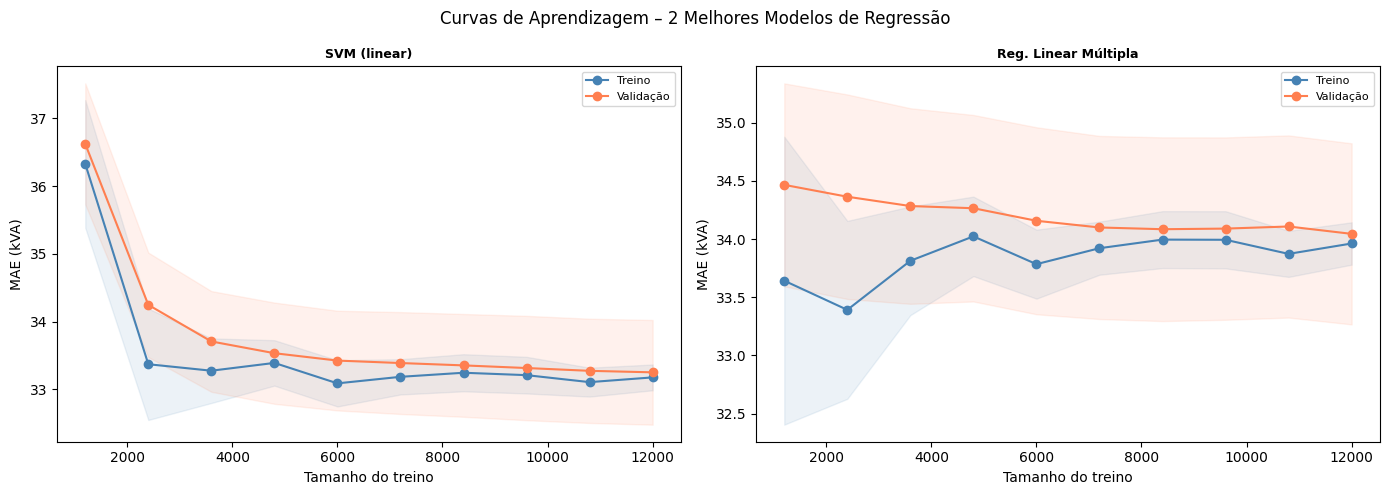

Interpretação: treino ≈ validação -> eficiente | validação >> treino -> overfitting | ambas altas -> underfitting


In [24]:
# 4.2.5 - Curvas de Aprendizagem dos 2 Melhores Modelos de Regressão
# A função plot_lc usa neg_mean_absolute_error; negamos para obter MAE positivo.
def plot_lc(model, Xd, yd, title, ax, scoring='neg_mean_absolute_error'):
    ts, tsc, vsc = learning_curve(
        model, Xd, yd,
        train_sizes=np.linspace(0.1, 1.0, 10), cv=5,
        scoring=scoring, n_jobs=-1)
    # neg_mean_absolute_error -> valores negativos; negamos para MAE positivo
    if scoring == 'neg_mean_absolute_error':
        tm  = (-tsc).mean(1)
        vm  = (-vsc).mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'MAE (kVA)'
    else:  # accuracy
        tm  = tsc.mean(1)
        vm  = vsc.mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'Accuracy'
    ax.plot(ts, tm, 'o-', color='steelblue', label='Treino')
    ax.plot(ts, vm, 'o-', color='coral',    label='Validação')
    ax.fill_between(ts, tm - ts_std, tm + ts_std, alpha=0.1, color='steelblue')
    ax.fill_between(ts, vm - vs_std, vm + vs_std, alpha=0.1, color='coral')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Tamanho do treino')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

# Seleccionar dinamicamente os 2 modelos com menor MAE médio
reg_results = {
    f'Árvore (d={best_d})':       (DecisionTreeRegressor(max_depth=best_d, random_state=SEED), X,        res_dt['MAE_mean']),
    'Reg. Linear Múltipla':       (LinearRegression(),                                         X_scaled,  res_lr['MAE_mean']),
    f'SVM ({best_k_svm})':        (SVR(kernel=best_k_svm, C=1.0),                              X_scaled,        res_svm['MAE_mean']),
    f'NN ({best_nn})':            (None,                                                        None,      nn_res[best_nn]['MAE_mean']),
}
# Excluir NN (não tem modelo sklearn para learning_curve)
reg_sklearn = {k: v for k, v in reg_results.items() if v[0] is not None}
sorted_reg = sorted(reg_sklearn.items(), key=lambda x: x[1][2])
top2_reg = sorted_reg[:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, (model, Xdata, _)) in enumerate(top2_reg):
    plot_lc(model, Xdata, y_reg, name, axes[i], scoring='neg_mean_absolute_error')
plt.suptitle('Curvas de Aprendizagem – 2 Melhores Modelos de Regressão', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretação: treino ≈ validação -> eficiente | validação >> treino -> overfitting | ambas altas -> underfitting')


#### Interpretação das Curvas de Aprendizagem, Regressão

Os 2 melhores modelos sklearn são o **SVM (linear)** (MAE = 33.22) e a 
**Regressão Linear Múltipla** (MAE = 34.03). A NN Shallow é o modelo 
globalmente melhor (MAE = 32.05) mas é excluída desta análise por 
incompatibilidade entre Keras e `learning_curve` do sklearn.

**SVM (linear):**

A curva revela treino **muito eficiente**, sem sinais de overfitting nem 
underfitting:

- A curva de treino (azul) começa em ~36.3 kVA com 1 200 amostras e desce 
  rapidamente para ~33.0 kVA por volta das 4 000 amostras, estabilizando 
  depois nesse valor.
- A curva de validação (vermelho) parte de ~36.6 kVA, desce em paralelo e 
  converge progressivamente para ~33.2 kVA.
- A partir de cerca de 6 000 amostras, treino e validação ficam 
  **praticamente sobrepostos** (gap inferior a 0.2 kVA), o que indica 
  capacidade de generalização excelente.
- O plateau atingido às ~6 000 amostras sugere que o modelo já extraiu 
  toda a informação disponível nas features. Adicionar mais dados não 
  melhoraria significativamente o desempenho.

**Regressão Linear Múltipla:**

A curva mostra um modelo **estável desde o início**, com gap pequeno e 
constante:

- A curva de treino (azul) oscila entre 33.4 e 34.0 kVA desde as 1 200 
  amostras. O modelo é tão simples que estabiliza imediatamente, sem 
  necessitar de mais dados para ajustar os coeficientes.
- A curva de validação (vermelho) começa em ~34.5 kVA e desce gradualmente 
  para ~34.0 kVA.
- O gap entre treino e validação é de aproximadamente 0.3 a 0.5 kVA, 
  pequeno e estável ao longo de todo o eixo. Não há sinais de overfitting 
  (val_loss não cresce) nem de underfitting (ambas em valores baixos e 
  consistentes).
- Tal como no SVM, atingiu plateau cedo, e mais dados não trariam ganho 
  perceptível.

**Comparação e impacto nos resultados:**

| | SVM (linear) | Reg. Linear Múltipla |
|--|---------------|------------------------|
| Treino final | ~33.0 | ~34.0 |
| Validação final | ~33.2 | ~34.0 |
| Gap treino/validação | Quase nulo | ~0.3 a 0.5 kVA |
| Plateau atingido | Sim (~6 000 amostras) | Sim (desde o início) |
| Diagnóstico | Treino eficiente, sem overfitting | Treino eficiente, sem overfitting |

Ambos os modelos exibem o **comportamento ideal**: treino e validação 
convergem para valores próximos, sem gap crescente nem oscilação. O 
SVM atinge MAE ligeiramente inferior à Regressão Linear Múltipla 
(33.2 vs 34.0), consistente com a tabela de 4.2.4.

Ambas as curvas estabilizam bem antes do final do eixo X, o que confirma 
a conclusão geral de 4.2.4: o **limite informativo das features** foi 
atingido, e a margem de melhoria não está em mais dados nem em modelos 
mais complexos, mas sim em incorporar features adicionais (geração 
distribuída, perfis horários, georreferenciação da IP) que captem 
estrutura preditiva atualmente ausente.

### 4.2.6 - Testes Estatísticos (α = 5%)

In [42]:
# 4.2.6 - Teste Estatístico entre os 2 Melhores Modelos de Regressão (α=5%)
# Inclui TODOS os modelos (incluindo NN), não apenas sklearn.

all_reg_folds = {
    f'Árvore (d={best_d})':    res_dt['MAE_folds'],
    'Reg. Linear Múltipla':    res_lr['MAE_folds'],
    f'SVM ({best_k_svm})':     res_svm['MAE_folds'],
    f'NN ({best_nn})':         nn_res[best_nn]['MAE_folds'],
}

sorted_all = sorted(all_reg_folds.items(), key=lambda x: np.mean(x[1]))
top2_name_1, top2_folds_1 = sorted_all[0]
top2_name_2, top2_folds_2 = sorted_all[1]

print(f'Comparando: {top2_name_1} (MAE={np.mean(top2_folds_1):.4f})  vs  '
      f'{top2_name_2} (MAE={np.mean(top2_folds_2):.4f})')

mae1 = np.array(top2_folds_1)
mae2 = np.array(top2_folds_2)
diffs = mae1 - mae2

_, p_sw = shapiro(diffs)
print(f'Shapiro-Wilk (diferenças MAE): p={p_sw:.4f}')
if p_sw > 0.05:
    stat, p = ttest_rel(mae1, mae2)
    tnm = 't-test pareado'
else:
    stat, p = wilcoxon(mae1, mae2)
    tnm = 'Wilcoxon signed-rank'

print(f'{tnm}: stat={stat:.4f}, p={p:.4f}')
if p < 0.05:
    winner = top2_name_1 if mae1.mean() < mae2.mean() else top2_name_2
    print(f'-> Diferença significativa (p<0.05). Melhor: {winner}')
else:
    print('-> Sem diferença significativa (p>=0.05). Os modelos têm desempenho equivalente.')

Comparando: NN (Config1_Shallow) (MAE=32.0545)  vs  SVM (linear) (MAE=33.2220)
Shapiro-Wilk (diferenças MAE): p=0.1020
t-test pareado: stat=-3.7676, p=0.0044
-> Diferença significativa (p<0.05). Melhor: NN (Config1_Shallow)


#### Interpretação, Teste Estatístico (Regressão)

Os dois melhores modelos por MAE são a **NN Config1_Shallow** (MAE = 32.05) 
e o **SVM linear** (MAE = 33.22), com diferença absoluta de 1.17 kVA. O 
objetivo desta secção é determinar se essa diferença é estatisticamente 
significativa ou se pode ser atribuída à variabilidade entre folds.

**Procedimento adotado:**

1. **Shapiro-Wilk** nas diferenças de MAE entre os 10 folds, para testar a 
   normalidade da distribuição das diferenças.
2. Se p > 0.05 (diferenças normais): aplica-se o **t-test pareado**. Caso 
   contrário, aplica-se o **Wilcoxon signed-rank** (não paramétrico).
3. Se o p-value do teste final for inferior a 0.05, conclui-se que a 
   diferença é estatisticamente significativa ao nível de 5%.

Os testes são **pareados** porque ambos os modelos foram avaliados nos 
mesmos 10 folds (`kf10` partilhado), o que reduz a variância entre 
comparações e aumenta o poder estatístico do teste.

**Resultados:**

| Etapa | Estatística | p-value | Decisão |
|-------|-------------|---------|---------|
| Shapiro-Wilk (diferenças) | (não reportado) | 0.1020 | Aceita normalidade |
| **t-test pareado** | **−3.7676** | **0.0044** | Diferença significativa |

**Interpretação:**

O p-value do Shapiro-Wilk (0.1020) é superior a 0.05, pelo que se aceita 
a hipótese de normalidade das diferenças e se aplica o **t-test pareado**.

O p-value do t-test (0.0044) é inferior a 0.05, indicando que a diferença 
entre a NN Shallow e o SVM linear é **estatisticamente significativa** ao 
nível de 5%. A estatística t negativa (−3.7676) confirma que a NN tem MAE 
inferior em praticamente todos os folds: a probabilidade de observar uma 
diferença tão grande (ou maior) por mero acaso, assumindo desempenho 
idêntico, é de apenas 0.44%.

**A NN Config1_Shallow é, portanto, identificada como o melhor modelo de 
regressão**, com vantagem estatisticamente significativa sobre o SVM linear.

**Nota sobre a magnitude do efeito:**

A diferença absoluta em MAE (1.17 kVA) é pequena face à escala da 
`PFolga_PTD` (mediana cerca de 77 kVA). O teste estatístico confirma 
apenas que essa diferença não é fruto do acaso, não que seja 
operacionalmente relevante. Para PTDs pequenos esta diferença pode 
representar variação significativa do erro relativo, enquanto para PTDs 
grandes é praticamente residual. A escolha entre os dois modelos deve 
ponderar também critérios práticos como interpretabilidade (o SVM 
linear é mais transparente que a NN, com coeficientes diretamente 
inspecionáveis) e custo computacional (o SVM treina em segundos contra 
dezenas de segundos por fold da NN).

---
## 4.3. Classificação - Previsão de utilizRede
### 4.3.0 - Criar variável utilizRede

Distribuição:
utilizRede
baixo    7611
medio    3732
alto     3657
Name: count, dtype: int64

Proporções (%):
utilizRede
baixo    50.7
medio    24.9
alto     24.4
Name: proportion, dtype: float64


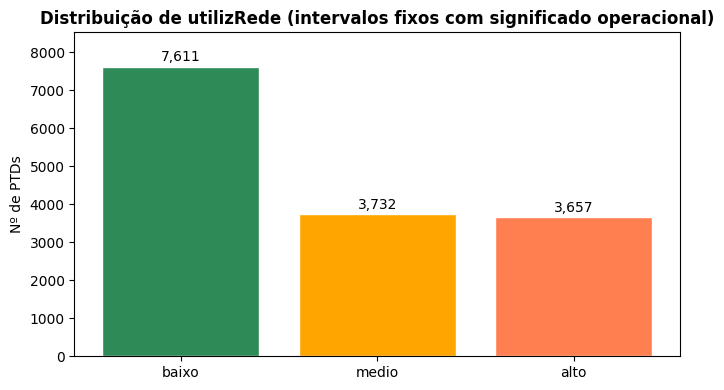

In [26]:
# Discretização de Util_Decimal em 3 classes por intervalos fixos
# Justificação: Util_Decimal é uma variável discreta com apenas 6 valores
# distintos (0.19, 0.39, 0.59, 0.79, 0.99, 1.00), inviabilizando uma
# divisão por tercis equilibrada — o valor 0.39 representa ~30% do dataset
# e tem de pertencer integralmente a uma classe.
# Os limiares escolhidos têm significado operacional:
#   baixo  (< 0.50): PTD com folga confortável
#   medio  (0.50 – 0.75): PTD em zona de atenção
#   alto   (> 0.75): PTD próximo dos limites operacionais

df_clean = df_clean.copy()
df_clean['utilizRede'] = pd.cut(
    df_clean['Util_Decimal'],
    bins=[-np.inf, 0.50, 0.75, np.inf],
    labels=['baixo', 'medio', 'alto']
)

print('Distribuição:')
dist = df_clean['utilizRede'].value_counts().sort_index()
print(dist)
print('\nProporções (%):')
print((df_clean['utilizRede'].value_counts(normalize=True).sort_index() * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist.index, dist.values, color=['seagreen', 'orange', 'coral'], edgecolor='white')
for bar, val in zip(ax.patches, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title('Distribuição de utilizRede (intervalos fixos com significado operacional)',
             fontweight='bold')
ax.set_ylabel('Nº de PTDs')
ax.set_ylim(0, max(dist.values) * 1.12)
plt.tight_layout()
plt.savefig('fig_utilizRede.png', dpi=150, bbox_inches='tight')
plt.show()

#### Justificação da Discretização, utilizRede

A variável `utilizRede` foi criada a partir de `Util_Decimal` com base em 
**intervalos fixos com significado operacional**.

Foi inicialmente considerada uma discretização por tercis (`pd.qcut`), mas a 
análise revelou que `Util_Decimal` é uma variável **discreta** com apenas 6 
valores distintos (0.19, 0.39, 0.59, 0.79, 0.99, 1.00). O valor 0.39 
representa cerca de 30% do dataset, tornando qualquer divisão por quantis 
impossível de equilibrar: todos os PTDs com esse valor pertencem 
obrigatoriamente à mesma classe.

Os limiares foram definidos com base no significado operacional no contexto 
da rede eléctrica:

| Classe | Intervalo | Significado |
|--------|-----------|-------------|
| `baixo` | Util_Decimal ≤ 0.50 | PTD com folga confortável, viável para VE sem intervenção |
| `medio` | 0.50 < Util_Decimal ≤ 0.75 | PTD em zona de atenção, viabilidade condicionada |
| `alto`  | Util_Decimal > 0.75 | PTD próximo dos limites operacionais, risco de sobrecarga |

**Distribuição resultante (15 000 registos):**

| Classe | N | % |
|--------|---|---|
| `baixo` | 7 611 | 50.7% |
| `medio` | 3 732 | 24.9% |
| `alto` | 3 657 | 24.4% |

A distribuição é desbalanceada (cerca de 51% / 25% / 24%), consequência 
direta da natureza discreta dos dados originais e não de uma escolha 
metodológica.

In [27]:
# Features de classificação (idênticas às da regressão)
# Util_Decimal já foi excluída no pré-processamento (data leakage direto —
# utilizRede é derivada de Util_Decimal)
FEATURES_CLF = FEATURES.copy()
X_clf = df_clean[FEATURES_CLF].values
y_clf = df_clean['utilizRede'].astype(str).values
X_clf_sc = StandardScaler().fit_transform(X_clf)
kf10c = KFold(n_splits=10, shuffle=True, random_state=SEED)
print(f'Features CLF ({len(FEATURES_CLF)}): shape={X_clf.shape}')
print(f'Features: {FEATURES_CLF}')

Features CLF (16): shape=(15000, 16)
Features: ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Tipo_Construtivo_enc']


In [28]:
# --- Subsample opcional para acelerar testes (estratificado por utilizRede) ---
if USE_SAMPLE:
    _df_smp = pd.DataFrame({"i": np.arange(len(y_clf)), "cls": y_clf})
    idx_sc  = (
        _df_smp.groupby("cls", group_keys=False)
               .apply(lambda g: g.sample(frac=SAMPLE_SIZE / len(y_clf), random_state=SEED))
    )["i"].values
    X_clf    = X_clf[idx_sc]
    X_clf_sc = X_clf_sc[idx_sc]
    y_clf    = y_clf[idx_sc]
    print(f"[USE_SAMPLE=True] Subsample estratificado: {len(y_clf)} registos | X_clf={X_clf.shape}")
    print("Distribuição:", pd.Series(y_clf).value_counts().sort_index().to_dict())
else:
    print(f"[USE_SAMPLE=False] Dataset completo | X_clf={X_clf.shape}")

[USE_SAMPLE=True] Subsample estratificado: 15000 registos | X_clf=(15000, 16)
Distribuição: {'alto': 3657, 'baixo': 7611, 'medio': 3732}


#### Features de Classificação

As features utilizadas na classificação são as **mesmas 16 features da 
regressão**. `Util_Decimal` foi excluída no pré-processamento (secção 4.1.3) 
por data leakage directo: `utilizRede` é derivada de `Util_Decimal`, pelo 
que incluí-la seria pedir ao modelo para prever a variável que gerou o 
próprio target.

Duas versões das features são mantidas ao longo da secção 4.3:

- **`X_clf`**: features na escala original, usada na Árvore de Decisão (que 
  é invariante a escala).
- **`X_clf_sc`**: features standardizadas com `StandardScaler`, usada em 
  SVM e KNN, que são sensíveis à magnitude das variáveis.

O `KFold` com 10 splits, shuffle e `random_state=SEED` (`kf10c`) é definido 
aqui e reutilizado em **todos os modelos de classificação**, garantindo que 
os folds são exactamente os mesmos.

### 4.3.1 - Modelos de Classificação

In [29]:
def eval_clf(model, Xd, yd, kf):
    a,p,r,f = [],[],[],[]
    for tr, te in kf.split(Xd):
        model.fit(Xd[tr], yd[tr])
        yp = model.predict(Xd[te])
        a.append(accuracy_score(yd[te], yp))
        p.append(precision_score(yd[te], yp, average='weighted', zero_division=0))
        r.append(recall_score(yd[te], yp, average='weighted', zero_division=0))
        f.append(f1_score(yd[te], yp, average='weighted', zero_division=0))
    return {'Acc':(np.mean(a),np.std(a)), 'Prec':(np.mean(p),np.std(p)),
            'Rec':(np.mean(r),np.std(r)), 'F1':(np.mean(f),np.std(f)), 'Acc_folds':a}

print('Função de avaliação definida.')

Função de avaliação definida.


#### Função de Avaliação — `eval_clf`

A função `eval_clf` centraliza a avaliação por k-fold CV para todos os modelos de classificação, garantindo que o processo é **idêntico e comparável** entre modelos.

Devolve um dicionário com média e desvio padrão de cada métrica, e a lista de Accuracy por fold (`Acc_folds`) necessária para os testes estatísticos pareados da secção 4.3.4.

| Parâmetro | Descrição |
|---|---|
| `model` | Classificador sklearn (Árvore, SVM, KNN) |
| `Xd` | Features `X_clf` (escala original) ou `X_clf_sc` (standardizado) |
| `yd` | Target array de strings `['baixo', 'medio', 'alto']` |
| `kf` | Objeto `KFold` partilhado por todos os modelos |

`average='weighted'` pondera cada classe pelo número de amostras adequado para classes desbalanceadas (51% / 25% / 24%). `zero_division=0` evita erros em folds onde uma classe minoritária não tem previsões.

In [30]:
print('=== a) Árvore de Decisão ===')
dcr = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_clf(DecisionTreeClassifier(max_depth=d, random_state=SEED), X_clf, y_clf, kf10c)
    dcr[d] = r
    print(f'  depth={str(d):4}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_dc = max(dcr, key=lambda d: dcr[d]['Acc'][0])
res_dtc = dcr[best_dc]
dt_clf = DecisionTreeClassifier(max_depth=best_dc, random_state=SEED).fit(X_clf, y_clf)
print(f'-> Melhor depth: {best_dc} | Acc: {res_dtc["Acc"][0]:.4f}')

=== a) Árvore de Decisão ===
  depth=3   : Acc=0.6717 ± 0.0113 | F1=0.6645
  depth=5   : Acc=0.6823 ± 0.0144 | F1=0.6589
  depth=7   : Acc=0.6884 ± 0.0106 | F1=0.6773
  depth=10  : Acc=0.6691 ± 0.0100 | F1=0.6581
  depth=15  : Acc=0.6355 ± 0.0081 | F1=0.6276
  depth=None: Acc=0.6139 ± 0.0077 | F1=0.6099
-> Melhor depth: 7 | Acc: 0.6884


#### 4.3.1a, Árvore de Decisão

A profundidade ótima é selecionada por **loop manual** sobre 6 valores de 
`max_depth` ([3, 5, 7, 10, 15, None]), escolhendo o que maximiza a Accuracy 
média nos 10 folds. `None` (profundidade ilimitada) serve como referência 
de overfitting puro.

**Resultados:**

| max_depth | Accuracy | F1 |
|-----------|----------|-----|
| 3 | 0.6717 ± 0.0113 | 0.6645 |
| 5 | 0.6823 ± 0.0144 | 0.6589 |
| **7** | **0.6884 ± 0.0106** | **0.6773** |
| 10 | 0.6691 ± 0.0100 | 0.6581 |
| 15 | 0.6355 ± 0.0081 | 0.6276 |
| None | 0.6139 ± 0.0077 | 0.6099 |

A profundidade ótima foi **d = 7** (Acc = 0.6884 ± 0.0106), confirmando o 
tradeoff bias-variance: profundidades menores (d=3, Acc=0.6717) subajustam, 
e profundidades excessivas (d=None, Acc=0.6139) memorizam o treino mas 
generalizam mal. A queda monótona de Accuracy a partir de d=7 é o sinal 
clássico de overfitting progressivo.

A diferença entre o melhor (d=7) e o pior (d=None) é de 7.5 pontos 
percentuais, o que mostra a importância de regularizar a árvore por 
profundidade neste problema.

Após selecção da profundidade ótima, o modelo é re-treinado em todo o 
subsample (`dt_clf`) exclusivamente para visualização da estrutura e 
cálculo da importância de features em 4.3.3. A avaliação de desempenho 
baseia-se nos resultados do k-fold (`res_dtc`), não no modelo final.

**Leitura da árvore visualizada (3 primeiros níveis):**

A raiz divide em `Cap_per_Cliente ≤ 2.476`, confirmando que a capacidade 
por cliente é a feature mais discriminante (analisada em detalhe em 4.3.3). 
Nos níveis seguintes surgem `PContratada_per_Cliente`, `Cap_PTD_kVA` e 
`N_Clientes`, variáveis associadas à dimensão e ao perfil de carga do PTD.

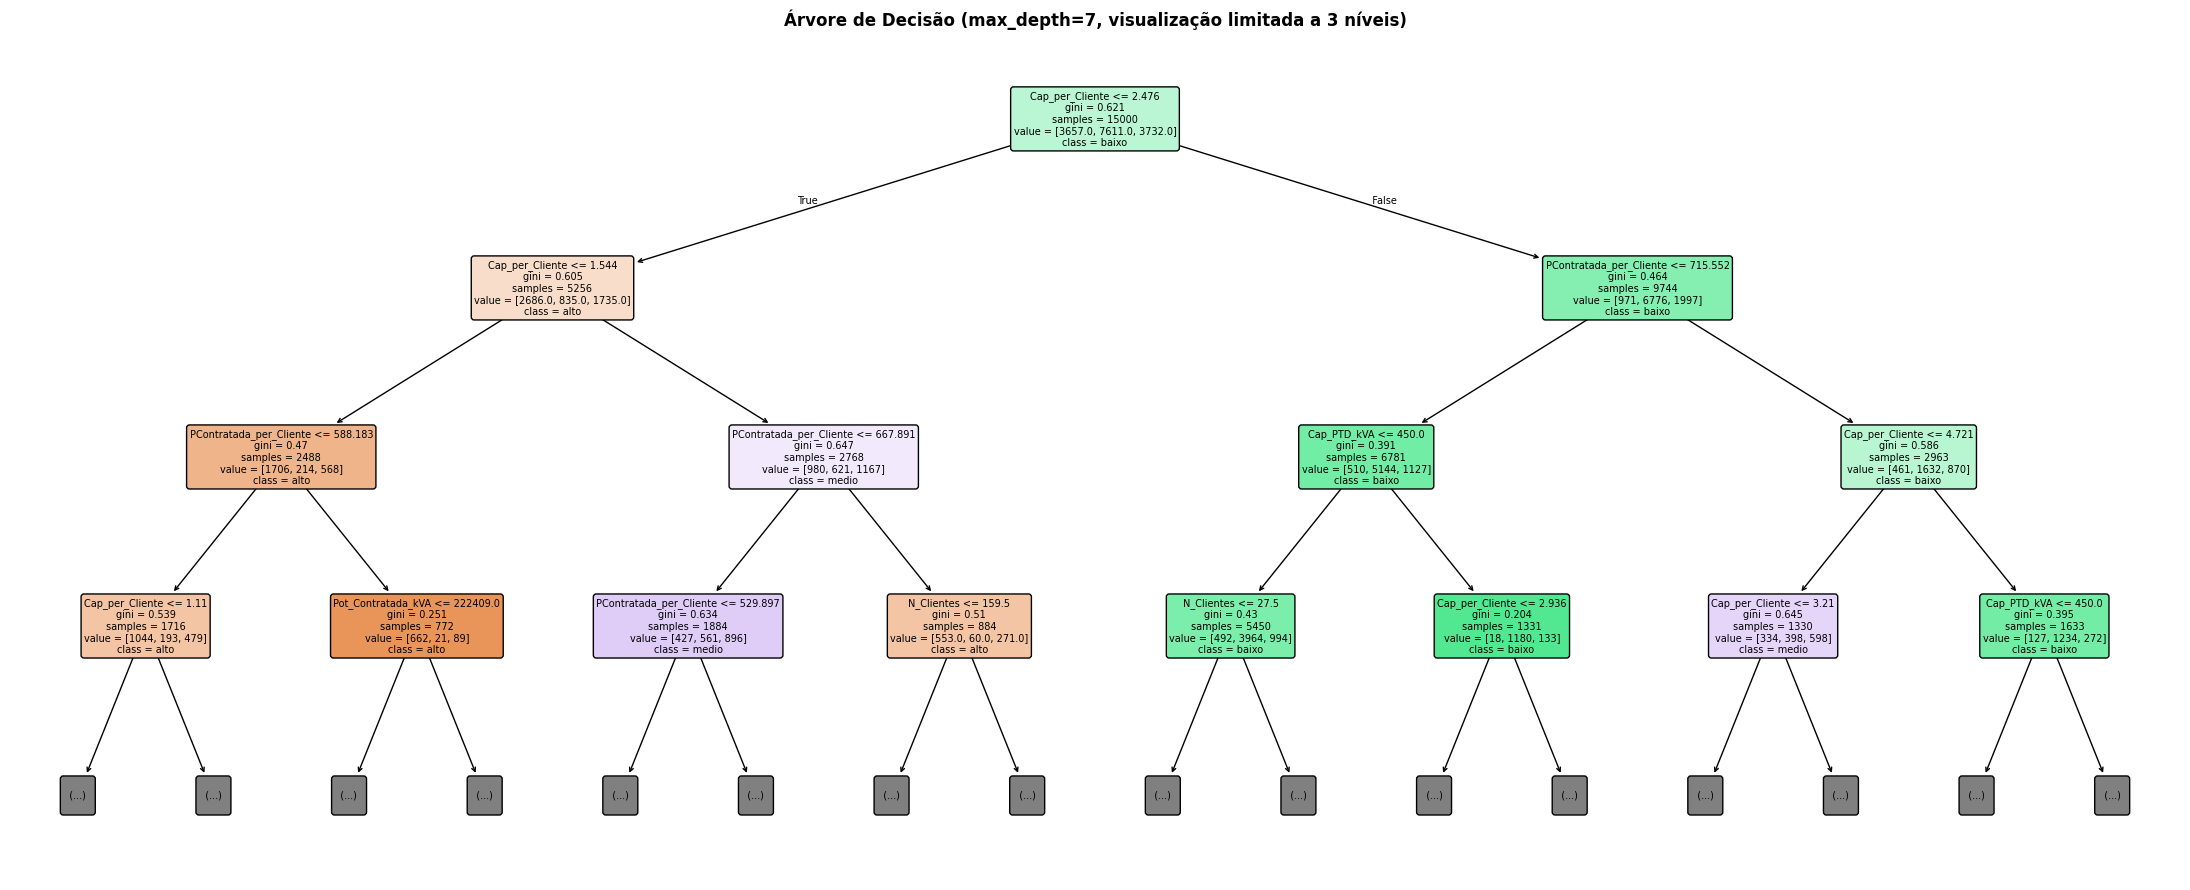

In [31]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_clf, max_depth=3, feature_names=FEATURES_CLF,
          class_names=dt_clf.classes_, filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(
    f'Árvore de Decisão (max_depth={best_dc}, visualização limitada a 3 níveis)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# b) Rede Neuronal Classificação – 3 configurações com k-fold CV
# Nota: para redes neuronais aplicamos k-fold treinando um modelo por fold.
# As curvas de loss são plotadas a partir do melhor fold (fold representativo).
print('=== b) Rede Neuronal Classificação (k-fold CV) ===')
le_c = LabelEncoder()
y_enc_all = le_c.fit_transform(y_clf)  # índices inteiros (globais)
es_c = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

nn_cc = [
    {'name': 'Config1_Shallow', 'units': [64, 32],          'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config2_Medium',  'units': [128, 64, 32],      'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config3_Deep',    'units': [256, 128, 64, 32], 'drop': 0.3, 'lr': 5e-4},
]

hist_clf, nn_cr = {}, {}

for cfg in nn_cc:
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    # Guardar histórico do último fold para curvas de loss (fold representativo)
    last_history = None
    for tr_idx, te_idx in kf10c.split(X_clf_sc):
        Xtr, Xte = X_clf_sc[tr_idx], X_clf_sc[te_idx]
        ytr_int, yte_int = y_enc_all[tr_idx], y_enc_all[te_idx]
        ytr_cat = to_categorical(ytr_int, 3)
        yte_cat = to_categorical(yte_int, 3)
        tf.random.set_seed(SEED)
        inp = keras.Input(shape=(X_clf_sc.shape[1],))
        x = inp
        for u in cfg['units']:
            x = layers.Dense(u, activation='relu')(x)
            x = layers.Dropout(cfg['drop'])(x)
        mc = keras.Model(inp, layers.Dense(3, activation='softmax')(x))
        mc.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
                   loss='categorical_crossentropy', metrics=['accuracy'])
        hc = mc.fit(Xtr, ytr_cat, validation_data=(Xte, yte_cat),
                    epochs=150, batch_size=256, callbacks=[es_c], verbose=0)
        last_history = hc.history
        ypc = np.argmax(mc.predict(Xte, verbose=0), 1)
        fold_acc.append(accuracy_score(yte_int, ypc))
        fold_prec.append(precision_score(yte_int, ypc, average='weighted', zero_division=0))
        fold_rec.append(recall_score(yte_int, ypc, average='weighted', zero_division=0))
        fold_f1.append(f1_score(yte_int, ypc, average='weighted', zero_division=0))
    hist_clf[cfg['name']] = last_history
    nn_cr[cfg['name']] = {
        'Acc':  (np.mean(fold_acc),  np.std(fold_acc)),
        'Prec': (np.mean(fold_prec), np.std(fold_prec)),
        'Rec':  (np.mean(fold_rec),  np.std(fold_rec)),
        'F1':   (np.mean(fold_f1),   np.std(fold_f1)),
        'Acc_folds': fold_acc,
    }
    r = nn_cr[cfg['name']]
    print(f"  {cfg['name']:22}: Acc={r['Acc'][0]:.4f}±{r['Acc'][1]:.4f} | F1={r['F1'][0]:.4f}±{r['F1'][1]:.4f}")

best_nnc = max(nn_cr, key=lambda k: nn_cr[k]['Acc'][0])
print(f'-> Melhor NN: {best_nnc}')


=== b) Rede Neuronal Classificação (k-fold CV) ===
  Config1_Shallow       : Acc=0.6029±0.0637 | F1=0.5317±0.1000
  Config2_Medium        : Acc=0.6217±0.0195 | F1=0.5498±0.0306
  Config3_Deep          : Acc=0.5755±0.0303 | F1=0.4794±0.0455
-> Melhor NN: Config2_Medium


#### 4.3.1b, Rede Neuronal (Classificação)

A NN é avaliada por **10-fold CV**, treinando um modelo novo por fold (o 
Keras não tem suporte directo a `cross_val_score`). O `EarlyStopping` é 
reinstanciado por fold para evitar contaminação de estado interno entre folds.

**Preparação do target:** as classes string são convertidas para inteiros 
via `LabelEncoder` e depois para one-hot encoding com `to_categorical`, 
formato exigido pela função de perda `categorical_crossentropy` com 
activação `softmax` na camada de saída.

**Configurações testadas:**

| Config | Camadas | Neurónios | Regularização | Learning Rate |
|--------|---------|-----------|---------------|---------------|
| Shallow | 2 | [64, 32] | Dropout 20% | 1e-3 |
| Medium | 3 | [128, 64, 32] | Dropout 20% | 1e-3 |
| Deep | 4 | [256, 128, 64, 32] | Dropout 30% | 5e-4 |

**Resultados (10-fold CV):**

| Config | Accuracy | F1 |
|--------|----------|-----|
| Shallow | 0.6029 ± 0.0637 | 0.5317 ± 0.1000 |
| **Medium** | **0.6217 ± 0.0195** | **0.5498 ± 0.0306** |
| Deep | 0.5755 ± 0.0303 | 0.4794 ± 0.0455 |

A **Config2 Medium** é a melhor configuração (Acc = 0.6217), mas todas as 
NNs têm desempenho **inferior à Árvore de Decisão** (0.6884) e ao SVM 
(0.6903 com kernel rbf, em 4.3.1c). Isto sugere que, para este problema, 
a fronteira de decisão não é suficientemente complexa para justificar o 
custo da NN.

A **Config1 Shallow** apresenta o **maior desvio padrão de todas as 
métricas** (Acc ±0.0637, F1 ±0.1000), reflexo de uma rede com menos 
capacidade que se torna muito sensível à composição de cada fold. Quando 
o fold de validação contém amostras representativas das classes 
minoritárias, o desempenho cai dramaticamente, daí a variância elevada.

A **Config3 Deep** tem o pior desempenho (Acc = 0.5755). O dropout 
elevado (30%) combinado com 4 camadas constitui regularização excessiva 
para este dataset, e a learning rate reduzida (5e-4) ainda piora a 
convergência em apenas 10 a 20 épocas. A configuração revela-se 
sub-treinada.

**Decisões de design:**

- **Early stopping com `patience=20`** (em vez do default 10): testes 
  preliminares mostraram que `patience=10` interrompia o treino das 
  configs com dropout ao fim de cerca de 10 épocas, antes da convergência 
  genuína. `patience=20` dá margem suficiente para a rede superar 
  oscilações induzidas pelo dropout.

- **Learning rate da Config3 reduzida para 5e-4**: redes profundas têm 
  superfícies de loss mais complexas, e passos de gradiente menores 
  garantem convergência mais estável e evitam overshooting.


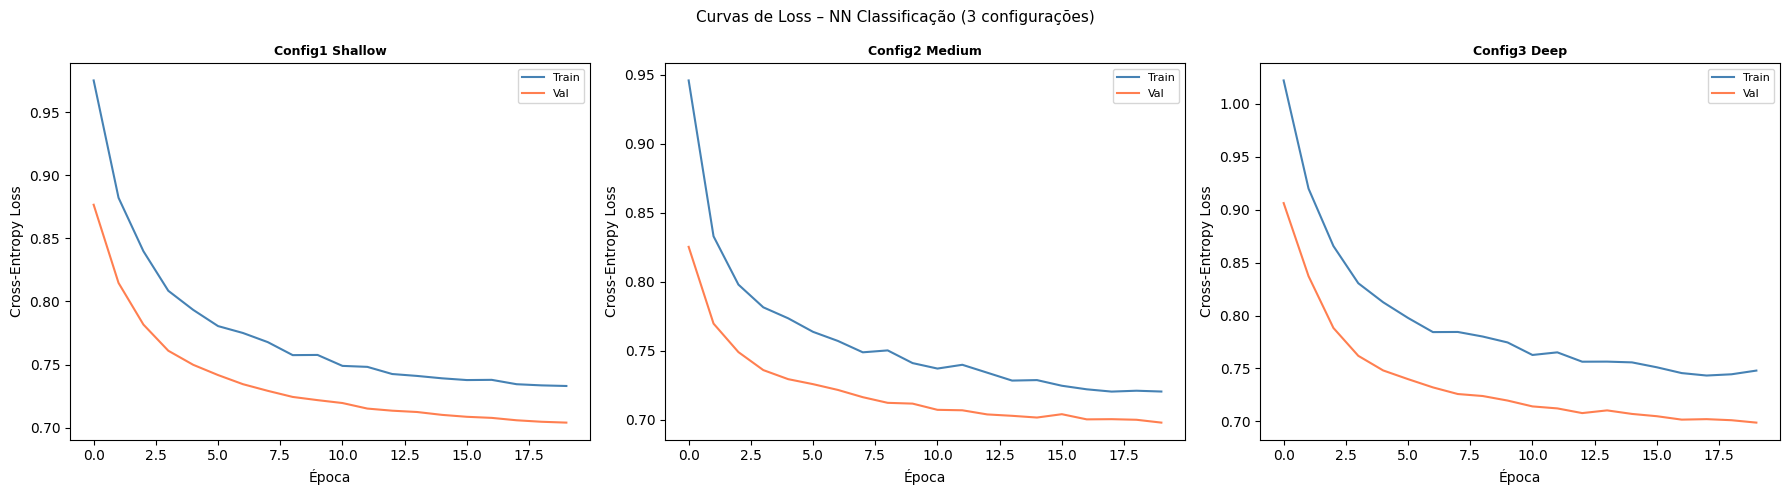

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cc):
    h = hist_clf[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Cross-Entropy Loss')
    axes[i].legend(fontsize=8)
    #(Config3: lr=5e-4, dropout=0.3)
plt.suptitle('Curvas de Loss – NN Classificação (3 configurações)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_nn_loss_clf.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação das curvas de loss:**

As três curvas mostram o mesmo padrão geral: descida suave da 
`train_loss` (azul) e `val_loss` (vermelho) ao longo das épocas, com 
`val_loss` consistentemente abaixo de `train_loss`. Este padrão é 
explicado pelo dropout: durante o treino, neurónios desactivados 
penalizam artificialmente a loss reportada, enquanto na validação 
o dropout está desactivado e a loss é mais baixa.

Não há sinais de overfitting (`val_loss` não cresce em nenhuma 
configuração), nem de underfitting clássico (ambas as curvas em valores 
moderados, não plataformas elevadas). A convergência observada em todas 
as configs para `val_loss ≈ 0.70` é coerente com a Accuracy da ordem dos 
0.60 a 0.62, e sugere que o **limite informativo das features foi atingido**: 
aumentar a complexidade da rede não traduz ganho real.

In [34]:
# c) SVM
print('=== c) SVM Classificação ===')
svc_r = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_clf(SVC(kernel=k, C=1.0, random_state=SEED),
                 X_clf_sc, y_clf, kf10c)
    svc_r[k] = r
    print(f'  kernel={k:6}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_ks = max(svc_r, key=lambda k: svc_r[k]['Acc'][0])
res_svc = svc_r[best_ks]
print(f'-> Melhor kernel: {best_ks}')

=== c) SVM Classificação ===
  kernel=linear: Acc=0.6693 ± 0.0163 | F1=0.6239
  kernel=rbf   : Acc=0.6903 ± 0.0100 | F1=0.6668
  kernel=poly  : Acc=0.6122 ± 0.0125 | F1=0.5454
-> Melhor kernel: rbf


#### 4.3.1c, SVM (Classificação)

O SVM é avaliado com **10-fold CV** (`kf10c`) sobre os mesmos 15 000 
registos do subsample global, com folds idênticos aos restantes modelos 
de classificação. Foram testados 3 kernels com `C=1.0` fixo:

**Resultados:**

| Kernel | Accuracy | F1 |
|--------|----------|-----|
| linear | 0.6693 ± 0.0163 | 0.6239 |
| **rbf** | **0.6903 ± 0.0100** | **0.6668** |
| poly | 0.6122 ± 0.0125 | 0.5454 |

O **kernel rbf** é o melhor (Acc = 0.6903), com vantagem clara sobre o 
linear (+2.1 pontos percentuais) e sobre o poly (+7.8 pontos). Esta 
preferência pelo `rbf` é interessante porque **contrasta com o resultado 
da regressão** (em 4.2.3.c o SVM linear venceu): a fronteira de decisão 
entre as classes `baixo`/`medio`/`alto` tem componente não-linear que o 
`rbf` capta com a sua capacidade de modelar regiões locais, enquanto a 
relação contínua entre features e `PFolga_PTD` (regressão) é 
essencialmente linear.

O kernel **poly** (Acc = 0.6122) apresenta o pior desempenho, sugerindo 
que fronteiras polinomiais globais não se adequam à estrutura local dos 
dados, e a sua maior variância na estimativa de fronteiras leva a 
performance significativamente inferior.

O kernel **linear** (Acc = 0.6693, ±0.0163) tem desempenho intermédio e 
desvio padrão razoável, estável mas limitado pela assunção de 
separabilidade linear.

**Comparação com restantes modelos:**

O SVM (rbf) é o **melhor classificador** desta análise (Acc = 0.6903), 
ligeiramente superior à Árvore de Decisão (0.6884). Esta proximidade 
sugere empate técnico, que o teste estatístico em 4.3.4 verificará 
formalmente.

Os hiperparâmetros `C` e `gamma` foram mantidos no default (o enunciado 
pede só optimização do kernel). Tuning conjunto poderia melhorar 
ligeiramente o desempenho do rbf, mas o resultado qualitativo (rbf 
domina) provavelmente mantém-se.

=== d) KNN – Otimização de K ===
  k= 1: Acc=0.5615 ± 0.0119 | F1=0.5634
  k= 3: Acc=0.6067 ± 0.0110 | F1=0.5990
  k= 5: Acc=0.6283 ± 0.0076 | F1=0.6094
  k= 7: Acc=0.6417 ± 0.0097 | F1=0.6234
  k=10: Acc=0.6423 ± 0.0066 | F1=0.6211
  k=15: Acc=0.6431 ± 0.0125 | F1=0.6204
  k=20: Acc=0.6446 ± 0.0104 | F1=0.6180
  k=30: Acc=0.6419 ± 0.0104 | F1=0.6103
  k=50: Acc=0.6423 ± 0.0109 | F1=0.6045
-> Melhor K: 20


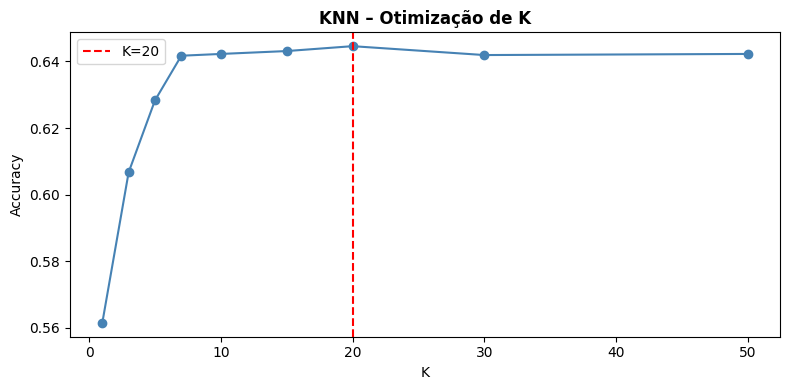

In [35]:
# d) KNN
print('=== d) KNN – Otimização de K ===')
knn_r = {}
for k in [1, 3, 5, 7, 10, 15, 20, 30, 50]:
    r = eval_clf(KNeighborsClassifier(n_neighbors=k), X_clf_sc, y_clf, kf10c)
    knn_r[k] = r
    print(f'  k={k:2}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_knn = max(knn_r, key=lambda k: knn_r[k]['Acc'][0])
res_knn = knn_r[best_knn]
print(f'-> Melhor K: {best_knn}')

fig, ax = plt.subplots(figsize=(8, 4))
ks = list(knn_r.keys())
ax.plot(ks, [knn_r[k]['Acc'][0] for k in ks], 'o-', color='steelblue')
ax.axvline(best_knn, color='red', ls='--', label=f'K={best_knn}')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.set_title('KNN – Otimização de K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3.1d, KNN (K-Vizinhos-Mais-Próximos)

K é optimizado por **loop manual** sobre [1, 3, 5, 7, 10, 15, 20, 30, 50], 
seleccionando o que maximiza a Accuracy média nos 10 folds. As features 
standardizadas (`X_clf_sc`) são obrigatórias para o KNN, pois distâncias 
euclidianas em escalas heterogéneas seriam dominadas pelas variáveis de 
maior magnitude (ex.: `Cap_PTD_kVA` em centenas de kVA contra `LED_Ratio` 
entre 0 e 1).

O mesmo `kf10c` é partilhado com os restantes modelos de classificação, 
garantindo folds idênticos.

**Resultados:**

| K | Accuracy | F1 |
|---|----------|-----|
| 1 | 0.5615 ± 0.0119 | 0.5634 |
| 3 | 0.6067 ± 0.0110 | 0.5990 |
| 5 | 0.6283 ± 0.0076 | 0.6094 |
| 7 | 0.6417 ± 0.0097 | 0.6234 |
| 10 | 0.6423 ± 0.0066 | 0.6211 |
| 15 | 0.6431 ± 0.0125 | 0.6204 |
| **20** | **0.6446 ± 0.0104** | **0.6180** |
| 30 | 0.6419 ± 0.0104 | 0.6103 |
| 50 | 0.6423 ± 0.0109 | 0.6045 |

O **K = 20** é o valor ótimo (Acc = 0.6446), confirmando o tradeoff 
bias-variance típico do KNN:

- **K = 1** apresenta o pior desempenho (Acc = 0.5615), uma queda de 
  cerca de 8 pontos percentuais face ao melhor. Com um único vizinho, 
  a classificação é extremamente sensível a outliers e ruído nos 
  dados, um caso clássico de overfitting.

- **K de 3 a 20**: Accuracy cresce consistentemente de 0.6067 para 0.6446. 
  Mais vizinhos estabilizam a fronteira de decisão e tornam a 
  classificação mais robusta, suavizando o efeito de outliers.

- **K de 20 a 50**: Accuracy decresce ligeiramente (0.6446 para 0.6423). 
  K demasiado grande introduz viés ao incluir vizinhos distantes que 
  podem pertencer a classes diferentes, distorcendo a classificação. 
  É underfitting marginal.

O **plateau entre K=7 e K=20** (Acc varia entre 0.6417 e 0.6446, menos 
de 0.3 pontos percentuais) mostra que o modelo é pouco sensível à 
escolha exata de K nesta região. Os desvios padrão são pequenos e 
estáveis (entre ±0.0066 e ±0.0125), confirmando que o KNN é consistente 
face à composição dos folds.

**Comparação com restantes modelos:**

O KNN (0.6446) fica em **terceiro lugar** entre os 4 classificadores 
testados:

| Posição | Modelo | Accuracy |
|---------|--------|----------|
| 1.º | SVM (rbf) | 0.6903 |
| 2.º | Árvore (d=7) | 0.6884 |
| 3.º | KNN (K=20) | 0.6446 |
| 4.º | NN (Medium) | 0.6217 |

O KNN bate a NN por margem clara (+2.3 pontos), mas fica cerca de 4.5 
pontos abaixo dos modelos top (SVM e Árvore). A classificação por 
vizinhança capta razoavelmente a estrutura local dos dados, mas falha 
em explorar interacções entre features que a Árvore e o SVM rbf 
conseguem modelar mais eficazmente.

**Limitações:**

O KNN não produz um modelo interpretável (não há coeficientes nem regras 
explícitas) e tem predição lenta, com complexidade O(n) por amostra ao 
calcular distâncias para todos os 15 000 PTDs de treino.

### 4.3.2 – Métricas (média ± desvio padrão)

In [36]:
# 4.3.2 – Métricas globais (média ± desvio padrão) e por classe
def fmt(m, s): return f'{m:.4f} ± {s:.4f}'
rnn = nn_cr[best_nnc]

# --- Tabela de métricas globais (10-fold CV, weighted) ---
results_clf = pd.DataFrame([
    {'Modelo': f'Árvore (d={best_dc})',
     'Accuracy': fmt(*res_dtc['Acc']), 'Precision': fmt(*res_dtc['Prec']),
     'Recall': fmt(*res_dtc['Rec']),   'F1': fmt(*res_dtc['F1'])},
    {'Modelo': f'NN ({best_nnc})',
     'Accuracy': fmt(*rnn['Acc']),     'Precision': fmt(*rnn['Prec']),
     'Recall': fmt(*rnn['Rec']),       'F1': fmt(*rnn['F1'])},
    {'Modelo': f'SVM ({best_ks})',
     'Accuracy': fmt(*res_svc['Acc']), 'Precision': fmt(*res_svc['Prec']),
     'Recall': fmt(*res_svc['Rec']),   'F1': fmt(*res_svc['F1'])},
    {'Modelo': f'KNN (k={best_knn})',
     'Accuracy': fmt(*res_knn['Acc']), 'Precision': fmt(*res_knn['Prec']),
     'Recall': fmt(*res_knn['Rec']),   'F1': fmt(*res_knn['F1'])},
])
print('=== Métricas Globais (10-fold CV, weighted) ===')
print(results_clf.to_string(index=False))

# --- Métricas por classe via cross_val_predict (10-fold, consistente com eval_clf) ---
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

def per_class_report(model, X, y_str, name, cv=10):
    """Métricas por classe via cross_val_predict — mesmo nº de folds que eval_clf."""
    y_pred = cross_val_predict(model, X, y_str, cv=cv)
    print(f'\n--- {name} (cross_val_predict {cv}-fold, por classe) ---')
    print(classification_report(y_str, y_pred, target_names=np.unique(y_str)))

per_class_report(
    DecisionTreeClassifier(max_depth=best_dc, random_state=SEED),
    X_clf, y_clf, f'Árvore (d={best_dc})')

per_class_report(
    SVC(kernel=best_ks, C=1.0, random_state=SEED),
    X_clf_sc, y_clf,
    f'SVM ({best_ks})')  

per_class_report(
    KNeighborsClassifier(n_neighbors=best_knn),
    X_clf_sc, y_clf, f'KNN (k={best_knn})')

# --- NN: report por classe num split representativo (80/20) ---
# cross_val_predict não é compatível com Keras — usamos um split representativo
print(f'\n--- NN ({best_nnc}) — report por classe (split 80/20 representativo) ---')
cfg_best = next(c for c in nn_cc if c['name'] == best_nnc)
es_report = EarlyStopping(monitor='val_loss', patience=20,
                          restore_best_weights=True, verbose=0)
tf.random.set_seed(SEED)
Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_clf_sc, y_enc_all, test_size=0.2, random_state=SEED)
ytr2_cat = to_categorical(ytr2, 3)
yte2_cat = to_categorical(yte2, 3)

inp2 = keras.Input(shape=(X_clf_sc.shape[1],))
x2 = inp2
for u in cfg_best['units']:
    x2 = layers.Dense(u, activation='relu')(x2)
    x2 = layers.Dropout(cfg_best['drop'])(x2)
mc2 = keras.Model(inp2, layers.Dense(3, activation='softmax')(x2))
mc2.compile(optimizer=keras.optimizers.Adam(cfg_best['lr']),
            loss='categorical_crossentropy', metrics=['accuracy'])
mc2.fit(Xtr2, ytr2_cat, validation_data=(Xte2, yte2_cat),
        epochs=150, batch_size=256, callbacks=[es_report], verbose=0)

yp_nn = np.argmax(mc2.predict(Xte2, verbose=0), 1)
print(classification_report(yte2, yp_nn, target_names=le_c.classes_))
print('Nota: report por classe da NN baseado num split representativo (80/20),')
print('não em CV — cross_val_predict não é compatível com Keras.')

=== Métricas Globais (10-fold CV, weighted) ===
             Modelo        Accuracy       Precision          Recall              F1
       Árvore (d=7) 0.6884 ± 0.0106 0.6740 ± 0.0142 0.6884 ± 0.0106 0.6773 ± 0.0138
NN (Config2_Medium) 0.6217 ± 0.0195 0.5888 ± 0.0247 0.6217 ± 0.0195 0.5498 ± 0.0306
          SVM (rbf) 0.6903 ± 0.0100 0.6704 ± 0.0094 0.6903 ± 0.0100 0.6668 ± 0.0116
         KNN (k=20) 0.6446 ± 0.0104 0.6163 ± 0.0123 0.6446 ± 0.0104 0.6180 ± 0.0120

--- Árvore (d=7) (cross_val_predict 10-fold, por classe) ---
              precision    recall  f1-score   support

        alto       0.69      0.63      0.66      3657
       baixo       0.76      0.86      0.80      7611
       medio       0.48      0.39      0.43      3732

    accuracy                           0.69     15000
   macro avg       0.64      0.63      0.63     15000
weighted avg       0.67      0.69      0.68     15000


--- SVM (rbf) (cross_val_predict 10-fold, por classe) ---
              precision    rec

#### 4.3.2, Métricas Globais e Por Classe

As métricas são calculadas com `average='weighted'`, que pondera cada classe 
pelo número de amostras. Esta escolha é adequada ao dataset desbalanceado 
(cerca de 51% / 25% / 24% para baixo / medio / alto). A média ± desvio 
padrão resulta dos 10 folds do k-fold CV: o desvio mede a estabilidade do 
modelo face à composição dos folds.

**Métricas Globais (10-fold CV, weighted):**

| Posição | Modelo | Accuracy | Precision | Recall | F1 |
|---------|--------|----------|-----------|--------|-----|
| 1.º | **SVM (rbf)** | **0.6903 ± 0.0100** | 0.6704 ± 0.0094 | 0.6903 ± 0.0100 | 0.6668 ± 0.0116 |
| 2.º | Árvore (d=7) | 0.6884 ± 0.0106 | 0.6740 ± 0.0142 | 0.6884 ± 0.0106 | **0.6773 ± 0.0138** |
| 3.º | KNN (k=20) | 0.6446 ± 0.0104 | 0.6163 ± 0.0123 | 0.6446 ± 0.0104 | 0.6180 ± 0.0120 |
| 4.º | NN (Config2_Medium) | 0.6217 ± 0.0195 | 0.5888 ± 0.0247 | 0.6217 ± 0.0195 | 0.5498 ± 0.0306 |

O **SVM (rbf)** apresenta a melhor Accuracy (0.6903) e o desvio padrão mais 
baixo (±0.0100), tornando-se o modelo mais estável entre folds. A **Árvore 
de Decisão (d=7)** é praticamente equivalente em Accuracy (0.6884) e tem na 
verdade o **melhor F1** (0.6773 contra 0.6668 do SVM). Os dois modelos top 
estão em empate técnico, e o teste estatístico em 4.3.4 verificará se a 
diferença é significativa.

O **KNN (k=20)** fica em terceiro lugar (Acc = 0.6446), claramente atrás dos 
dois top mas com desvio padrão baixo (±0.0104).

A **NN (Config2_Medium)** apresenta o pior desempenho global em todas as 
métricas (Acc = 0.6217, F1 = 0.5498) e o desvio padrão mais alto em todas 
elas (ex.: F1 ±0.0306). A dimensão reduzida do subsample (15 000 registos) 
limita a NN de forma desproporcional face aos outros modelos, pois redes 
neuronais beneficiam mais de volumes elevados de dados.

**Métricas Por Classe (cross_val_predict 10-fold, exceto NN):**

| Modelo | Classe | Precision | Recall | F1 |
|--------|--------|-----------|--------|-----|
| Árvore (d=7) | baixo | 0.76 | 0.86 | 0.80 |
|  | alto | 0.69 | 0.63 | 0.66 |
|  | medio | 0.48 | 0.39 | 0.43 |
| SVM (rbf) | baixo | 0.72 | 0.90 | 0.80 |
|  | alto | 0.70 | 0.64 | 0.67 |
|  | medio | 0.53 | 0.30 | 0.39 |
| KNN (k=20) | baixo | 0.70 | 0.88 | 0.78 |
|  | alto | 0.60 | 0.57 | 0.58 |
|  | medio | 0.45 | 0.25 | 0.32 |
| NN (Medium) | baixo | 0.76 | 0.88 | 0.82 |
|  | alto | 0.71 | 0.63 | 0.67 |
|  | medio | 0.51 | 0.39 | 0.44 |

**Padrão consistente entre todos os modelos:**

A classe `baixo` é sempre a melhor classificada (F1 entre 0.78 e 0.82), 
seguida de `alto` (F1 entre 0.58 e 0.67) e `medio` em último lugar 
(F1 entre 0.32 e 0.44). Esta hierarquia é consequência directa do 
desbalanceamento e da estrutura discreta de `Util_Decimal`.

**Por que `baixo` é sempre a melhor classe:**

É a classe maioritária (50.7%), pelo que os modelos têm mais exemplos para 
aprender os seus padrões. O recall elevado (0.86 a 0.90) indica que quase 
todos os PTDs realmente `baixo` são corretamente identificados.

**Por que `medio` é sempre a pior classe:**

A classe `medio` (24.9%) situa-se entre `baixo` e `alto` no eixo de 
utilização, e os PTDs nela colocados partilham características com as outras 
duas classes. As fronteiras de decisão são difusas. O recall é catastrófico: 
0.39 na Árvore, 0.30 no SVM, **0.25 no KNN**, o que significa que três quartos 
dos PTDs realmente `medio` são mal classificados.

**Por que Precision > Recall em `alto` e o inverso em `baixo`:**

- `baixo`: Recall alto, Precision moderada. Os modelos tendem a 
  sobre-classificar PTDs como `baixo` (viés para a classe maioritária), 
  capturando bem os casos reais mas gerando falsos positivos a partir de 
  `medio` e `alto`.
- `alto`: Precision mais alta, Recall mais baixo. Os modelos são 
  conservadores a atribuir a classe `alto`, errando menos quando a 
  atribuem mas falhando a identificar uma fração dos casos reais.

**Observação importante sobre o SVM:**

Apesar de o SVM (rbf) ter a melhor Accuracy global, é também o pior modelo 
no Recall da classe `medio` (0.30, contra 0.39 da Árvore e da NN). Por 
outras palavras: o SVM ganha pontos sendo melhor a identificar `baixo` 
(Recall 0.90), mas falha mais em `medio`. Para uma aplicação operacional 
onde identificar PTDs `medio` (zona de atenção) é prioritário, a **Árvore 
ou a NN podem ser preferíveis** ao SVM, apesar da Accuracy global inferior.

**Nota metodológica sobre a NN:**

As métricas por classe da NN baseiam-se num **split representativo 80/20** 
(treino com 12 000, teste com 3 000), não em `cross_val_predict`. Esta 
escolha é necessária porque o `cross_val_predict` do sklearn não é 
compatível com modelos Keras. Os valores da NN na tabela por classe 
(Acc = 0.70 no split) são compatíveis com a Accuracy do CV (0.62 ± 0.02), 
e a discrepância pequena confirma que o split é representativo do 
comportamento geral do modelo.

### 4.3.3 - Importância de features e comparação com correlações da 4.1

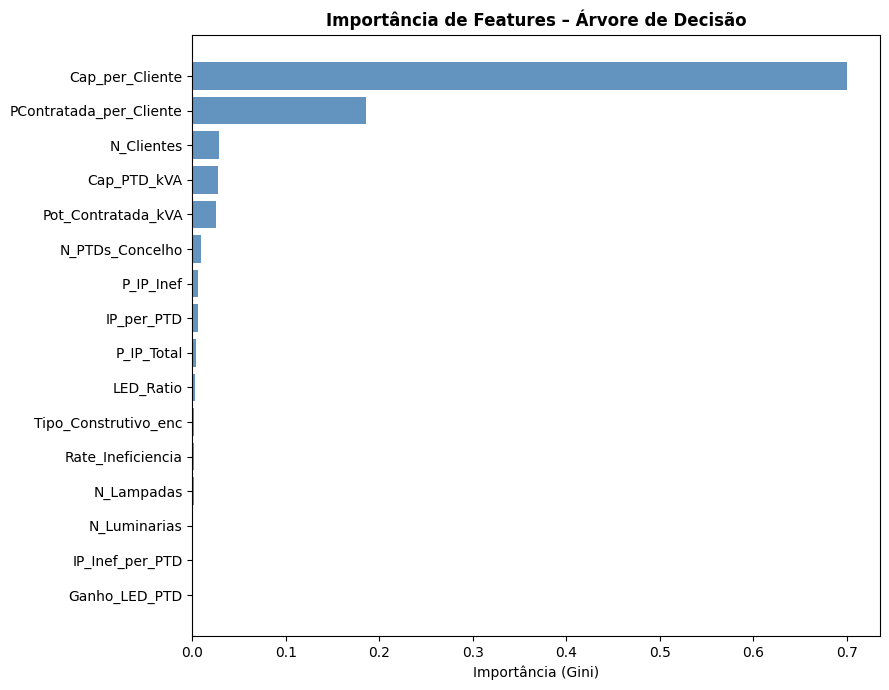

Top 5 features (classificação):
                Feature  Importance
        Cap_per_Cliente    0.700508
PContratada_per_Cliente    0.185890
             N_Clientes    0.028032
            Cap_PTD_kVA    0.027483
     Pot_Contratada_kVA    0.024743


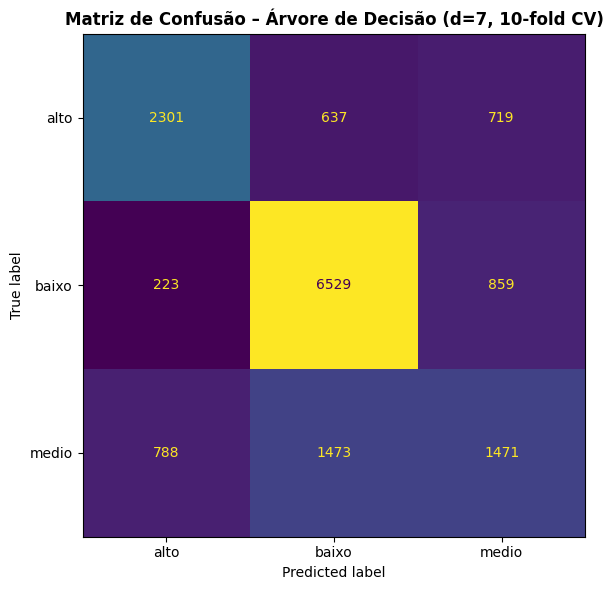

              precision    recall  f1-score   support

        alto       0.69      0.63      0.66      3657
       baixo       0.76      0.86      0.80      7611
       medio       0.48      0.39      0.43      3732

    accuracy                           0.69     15000
   macro avg       0.64      0.63      0.63     15000
weighted avg       0.67      0.69      0.68     15000



In [37]:
# 4.3.3 – Importância de features e matriz de confusão

fi_clf = pd.DataFrame({
    'Feature': FEATURES_CLF,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_clf['Feature'], fi_clf['Importance'], color='steelblue', alpha=0.85)
ax.set_xlabel('Importância (Gini)')
ax.set_title('Importância de Features – Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_clf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features (classificação):')
print(fi_clf.tail(5)[['Feature', 'Importance']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))

# --- Matriz de confusão via cross_val_predict (consistente com k-fold) ---
# Usar um modelo separado para não sobrescrever dt_clf
dt_cm = DecisionTreeClassifier(max_depth=best_dc, random_state=SEED)
y_pred_cm = cross_val_predict(dt_cm, X_clf, y_clf, cv=10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_clf, y_pred_cm, ax=ax,
    display_labels=np.unique(y_clf), colorbar=False)
ax.set_title(f'Matriz de Confusão – Árvore de Decisão (d={best_dc}, 10-fold CV)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_clf, y_pred_cm, target_names=np.unique(y_clf)))

#### 4.3.3, Importância de Features e Matriz de Confusão

**Importância de Features, Árvore de Decisão**

| Feature | Importância |
|---------|--------------------|
| `Cap_per_Cliente` | 0.7005 |
| `PContratada_per_Cliente` | 0.1859 |
| `N_Clientes` | 0.0280 |
| `Cap_PTD_kVA` | 0.0275 |
| `Pot_Contratada_kVA` | 0.0247 |

A importância de features mede a redução média de impureza de Gini 
atribuída a cada variável nos splits da árvore. As restantes 11 features 
têm importância próxima de zero e não contribuem para a classificação.

**`Cap_per_Cliente` domina com 70%.** A capacidade do PTD por cliente é o 
preditor mais discriminante do nível de ocupação da rede. Faz sentido 
operacional: um PTD com muita capacidade por cliente tem folga elevada 
(classe `baixo`), enquanto um PTD sobrecarregado por cliente tende a 
estar em `alto`.

**`PContratada_per_Cliente` contribui com cerca de 19%**, complementando 
`Cap_per_Cliente`. A potência contratada por cliente capta o perfil de 
consumo real (não apenas a capacidade instalada), permitindo distinguir 
PTDs com a mesma capacidade mas com clientes mais ou menos exigentes.

**As restantes 14 features contribuem com menos de 11% combinadas.** 
`N_Clientes`, `Cap_PTD_kVA` e `Pot_Contratada_kVA` têm importância 
residual (cerca de 2 a 3% cada), e todas as variáveis de iluminação 
pública (`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD`, etc.) têm 
importância praticamente nula. Isto confirma quantitativamente que o 
impacto da transição LED no nível de ocupação da rede ao nível do PTD 
individual é marginal, em linha com o diagnóstico de 4.2.1.

**Comparação com as correlações de 4.2.1:**

Há aqui um resultado interessante. A matriz de correlação mostrava 
`Cap_PTD_kVA` como a variável mais correlacionada com `PFolga_PTD` 
(r = 0.91), mas na classificação a Árvore atribui-lhe apenas cerca de 
3% de importância. Em contraste, `Cap_per_Cliente` (importância 70%) 
tinha apenas r = 0.59 com `PFolga_PTD`.

Esta inversão explica-se pelo facto de a `utilizRede` ser derivada de 
`Util_Decimal`, que é em si um rácio onde a capacidade absoluta do PTD 
está embebida. Por outras palavras: quando se prevê a folga absoluta 
(`PFolga_PTD`, regressão), a capacidade absoluta `Cap_PTD_kVA` é o 
fator dominante; quando se prevê o nível de ocupação relativa 
(`utilizRede`, classificação), o que discrimina as classes é a 
capacidade **por cliente**, não a capacidade absoluta. O modelo de 
classificação extrai informação diferente das mesmas features.

---

**Matriz de Confusão (Árvore d=7, 10-fold CV)**

|  | Previsto: alto | Previsto: baixo | Previsto: medio |
|--|----------------|------------------|------------------|
| **Real: alto** (3 657) | 2 301 ✓ | 637 | 719 |
| **Real: baixo** (7 611) | 223 | 6 529 ✓ | 859 |
| **Real: medio** (3 732) | 788 | 1 473 | 1 471 ✓ |

**Classe `baixo` (melhor desempenho, recall = 0.86):**

6 529 de 7 611 PTDs corretamente classificados. Os 1 082 erros distribuem-se 
maioritariamente para `medio` (859), o que é o erro menos grave: trata-se 
de PTDs na fronteira entre carga baixa e média, em que a folga ainda 
permite considerar instalação de VE com cuidado.

**Classe `alto` (desempenho intermédio, recall = 0.63):**

2 301 de 3 657 corretamente classificados. Os 1 356 erros dividem-se 
quase igualmente entre `baixo` (637) e `medio` (719). Os PTDs realmente 
`alto` mal classificados como `baixo` representam o **risco operacional 
mais grave**: o modelo identifica como tendo folga PTDs que estão 
próximos do limite, o que pode justificar instalação de VE sem 
capacidade real.

**Classe `medio` (pior desempenho, recall = 0.39):**

Apenas 1 471 de 3 732 corretamente classificados. A maioria dos erros 
vai para `baixo` (1 473, quase 40% dos `medio`), confirmando o viés do 
modelo para a classe maioritária. PTDs `medio` mal classificados como 
`baixo` representam o **principal ponto fraco** do classificador, e o 
mesmo problema verifica-se em todos os outros modelos (4.3.2).

**Conclusão operacional:**

O modelo é eficaz para identificar PTDs de baixa ocupação (candidatos 
prioritários para instalação de VE), com recall de 0.86. Mas falha em 
discriminar os níveis intermédios: 2 332 PTDs (das classes `medio` e 
`alto` combinadas) são erradamente atribuídos à classe `baixo`. Numa 
aplicação real, isto traduzir-se-ia em PTDs identificados como aptos 
para receber carregadores VE mas que, na verdade, estão em zona de 
atenção ou próximos dos limites operacionais.

### 4.3.4 - Teste Estatístico (α = 5%)

In [38]:
# 4.3.4 - Teste Estatístico entre os 2 Melhores Modelos de Classificação (α=5%)
clf_scores_paired = {
    f'Árvore (d={best_dc})': res_dtc['Acc_folds'],
    f'NN ({best_nnc})':       nn_cr[best_nnc]['Acc_folds'],
    f'SVM ({best_ks})':       res_svc['Acc_folds'],
    f'KNN (k={best_knn})':   res_knn['Acc_folds'],
}
sorted_clf = sorted(clf_scores_paired.items(), key=lambda x: np.mean(x[1]), reverse=True)
top2_name_1, top2_folds_1 = sorted_clf[0]
top2_name_2, top2_folds_2 = sorted_clf[1]
print(f'Comparando: {top2_name_1} (Acc={np.mean(top2_folds_1):.4f})  vs  {top2_name_2} (Acc={np.mean(top2_folds_2):.4f})')

f1_arr = np.array(top2_folds_1)
f2_arr = np.array(top2_folds_2)
diffs_clf = f1_arr - f2_arr

_, p_sw_clf = shapiro(diffs_clf)
print(f'Shapiro-Wilk (diferenças Accuracy): p={p_sw_clf:.4f}')
if p_sw_clf > 0.05:
    stat_c, p_c = ttest_rel(f1_arr, f2_arr)
    tn_c = 't-test pareado'
else:
    stat_c, p_c = wilcoxon(f1_arr, f2_arr)
    tn_c = 'Wilcoxon signed-rank'

print(f'{tn_c}: stat={stat_c:.4f}, p={p_c:.4f}')
if p_c < 0.05:
    w_c = top2_name_1 if f1_arr.mean() > f2_arr.mean() else top2_name_2
    print(f'-> Diferença significativa (p<0.05). Melhor modelo: {w_c}')
else:
    print(f'-> Sem diferença significativa (p>=0.05). Os modelos têm desempenho equivalente.')

Comparando: SVM (rbf) (Acc=0.6903)  vs  Árvore (d=7) (Acc=0.6884)
Shapiro-Wilk (diferenças Accuracy): p=0.3420
t-test pareado: stat=0.6981, p=0.5027
-> Sem diferença significativa (p>=0.05). Os modelos têm desempenho equivalente.


#### 4.3.4, Teste Estatístico (α = 5%)

Os dois melhores modelos por Accuracy são o **SVM (rbf)** (Acc = 0.6903) e a 
**Árvore (d=7)** (Acc = 0.6884), com diferença absoluta de apenas 0.0019 
(0.19 pontos percentuais). O objetivo desta secção é determinar se essa 
diferença é estatisticamente significativa ou se pode ser atribuída à 
variabilidade entre folds.

**Procedimento adotado:**

1. **Shapiro-Wilk** nas diferenças de Accuracy entre os 10 folds, para testar 
   a normalidade da distribuição das diferenças.
2. Se p > 0.05 (diferenças normais): aplica-se o **t-test pareado**. Caso 
   contrário, aplica-se o **Wilcoxon signed-rank** (não paramétrico).
3. Se o p-value do teste final for inferior a 0.05, conclui-se que a 
   diferença é estatisticamente significativa ao nível de 5%.

Os testes são **pareados** porque ambos os modelos foram avaliados nos 
mesmos 10 folds (`kf10c` partilhado), o que reduz a variância entre 
comparações e aumenta o poder estatístico.

**Resultados:**

| Etapa | Estatística | p-value | Decisão |
|-------|-------------|---------|---------|
| Shapiro-Wilk (diferenças) | (não reportado) | 0.3420 | Aceita normalidade |
| **t-test pareado** | **0.6981** | **0.5027** | Sem diferença significativa |

**Interpretação:**

O p-value do Shapiro-Wilk (0.3420) é superior a 0.05, pelo que se aceita 
a hipótese de normalidade das diferenças e se aplica o **t-test pareado**.

O p-value do t-test (0.5027) é superior a 0.05, o que indica que a 
diferença entre o SVM (rbf) e a Árvore (d=7) **não é estatisticamente 
significativa** ao nível de 5%. Por outras palavras: assumindo que os 
dois modelos têm desempenho idêntico, há cerca de 50% de probabilidade 
de observar uma diferença tão grande ou maior por mero acaso.

Os dois modelos têm, portanto, **desempenho estatisticamente equivalente** 
em Accuracy. A vantagem aparente do SVM (rbf) sobre a Árvore (0.19 pontos 
percentuais) deve-se à variabilidade natural entre folds, não a uma 
superioridade real do modelo.

**Escolha entre os dois modelos:**

Dado o empate estatístico, a decisão deve basear-se em critérios secundários:

| Critério | SVM (rbf) | Árvore (d=7) | Vencedor |
|----------|-----------|--------------|----------|
| Accuracy global | 0.6903 ± 0.0100 | 0.6884 ± 0.0106 | SVM (marginal) |
| F1 global | 0.6668 | 0.6773 | **Árvore** |
| Recall classe `medio` | 0.30 | 0.39 | **Árvore** |
| Interpretabilidade | Caixa negra | Regras explícitas | **Árvore** |
| Custo computacional | Treino lento (O(n²)) | Treino rápido | **Árvore** |
| Estabilidade entre folds | ±0.0100 | ±0.0106 | SVM (marginal) |

A **Árvore de Decisão (d=7)** é preferível neste contexto:

1. **Melhor F1** (0.6773 contra 0.6668): captura melhor o equilíbrio entre 
   Precision e Recall, métrica mais informativa que a Accuracy num dataset 
   desbalanceado.
2. **Melhor Recall na classe `medio`** (0.39 contra 0.30): identifica mais 
   correctamente os PTDs em zona de atenção, critério operacional crítico 
   para o caso de uso de mobilidade eléctrica.
3. **Interpretabilidade directa** através da visualização da árvore (4.3.1a) 
   e da importância de features (4.3.3), o que facilita a defesa do modelo 
   junto de operadores da rede.
4. **Custo computacional muito inferior**, treino instantâneo contra 
   minutos do SVM, vantagem em ambientes de produção.

A vantagem marginal do SVM em Accuracy (0.19 pontos) e estabilidade 
(±0.0006 menos de desvio) não compensa as desvantagens acima.

**Nota:**

Os dois modelos top são estatisticamente equivalentes em Accuracy 
(p = 0.5027). A escolha recai na **Árvore de Decisão (d=7)** por 
critérios secundários, em particular o melhor desempenho na classe 
`medio` (operacionalmente crítica) e a interpretabilidade que permite 
auditar as decisões do modelo.

### 4.3.5 - Curvas de Aprendizagem (melhor e pior modelo)

In [39]:
# Função auxiliar – curvas de aprendizagem (usada em 4.2.5 e 4.3.5)
from sklearn.model_selection import learning_curve

def plot_lc(model, Xd, yd, title, ax, scoring='neg_mean_absolute_error'):
    ts, tsc, vsc = learning_curve(
        model, Xd, yd,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=5, scoring=scoring, n_jobs=-1)

    if scoring == 'neg_mean_absolute_error':
        tm     = (-tsc).mean(1)
        vm     = (-vsc).mean(1)
        ts_std = (-tsc).std(1)
        vs_std = (-vsc).std(1)
        ylabel = 'MAE (kVA)'
    else:
        tm     = tsc.mean(1)
        vm     = vsc.mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'Accuracy'

    ax.plot(ts, tm, 'o-', color='steelblue', label='Treino')
    ax.plot(ts, vm, 'o-', color='coral',     label='Validação')
    ax.fill_between(ts, tm - ts_std, tm + ts_std, alpha=0.1, color='steelblue')
    ax.fill_between(ts, vm - vs_std, vm + vs_std, alpha=0.1, color='coral')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Tamanho do treino')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

Melhor modelo sklearn: SVM (rbf) (Acc=0.6903)
Pior  modelo sklearn: KNN (k=20) (Acc=0.6446)
(NN excluída — learning_curve não compatível com Keras)


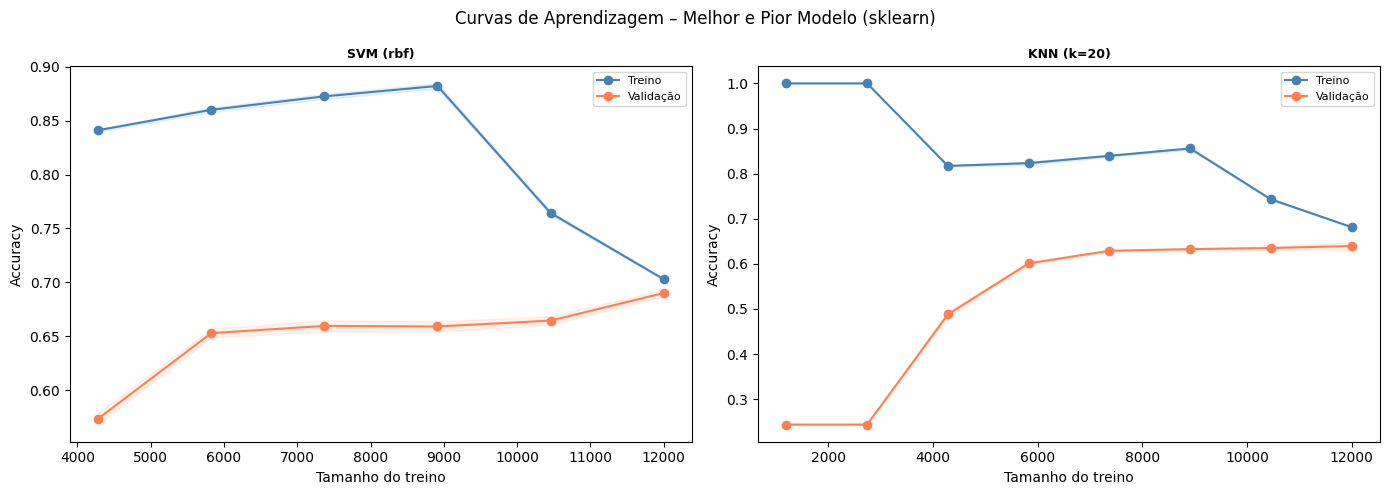

In [40]:
# 4.3.5 - Curvas de Aprendizagem: Melhor e Pior Modelo de Classificação
# Nota: a NN não tem suporte em learning_curve (Keras) — comparação feita
# entre os modelos sklearn. Se a NN for o melhor/pior modelo global,
# as curvas correspondem ao 2º melhor / 2º pior sklearn.

clf_sklearn_scores = {
    f'Árvore (d={best_dc})': (DecisionTreeClassifier(max_depth=best_dc, random_state=SEED),
                               X_clf, np.mean(res_dtc['Acc_folds'])),
    f'SVM ({best_ks})':      (SVC(kernel=best_ks, C=1.0, random_state=SEED),
                               X_clf_sc, np.mean(res_svc['Acc_folds'])),
    f'KNN (k={best_knn})':   (KNeighborsClassifier(n_neighbors=best_knn),
                               X_clf_sc, np.mean(res_knn['Acc_folds'])),
}

sorted_clf_sk = sorted(clf_sklearn_scores.items(), key=lambda x: x[1][2], reverse=True)
best_clf_name,  (best_clf_model,  best_clf_X,  _) = sorted_clf_sk[0]
worst_clf_name, (worst_clf_model, worst_clf_X, _) = sorted_clf_sk[-1]

print(f'Melhor modelo sklearn: {best_clf_name} (Acc={sorted_clf_sk[0][1][2]:.4f})')
print(f'Pior  modelo sklearn: {worst_clf_name} (Acc={sorted_clf_sk[-1][1][2]:.4f})')
print(f'(NN excluída — learning_curve não compatível com Keras)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(best_clf_model,  best_clf_X,  y_clf, best_clf_name,  axes[0], scoring='accuracy')
plot_lc(worst_clf_model, worst_clf_X, y_clf, worst_clf_name, axes[1], scoring='accuracy')

plt.suptitle('Curvas de Aprendizagem – Melhor e Pior Modelo (sklearn)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_clf.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3.5, Curvas de Aprendizagem

O melhor modelo sklearn é o **SVM (rbf)** (Acc = 0.6903) e o pior é o 
**KNN (k=20)** (Acc = 0.6446). A NN é excluída desta análise por 
incompatibilidade entre Keras e `learning_curve` do sklearn, pelo que as 
curvas correspondem ao melhor e pior modelo sklearn.

**SVM (rbf), Melhor Modelo:**

A curva revela um padrão de **regularização progressiva por escala de 
treino**:

- A curva de treino (azul) começa em ~0.84 com 4 500 amostras, sobe 
  ligeiramente para ~0.88 com 9 000 amostras, e depois **desce 
  rapidamente para ~0.70 com 12 000 amostras**. Esta descida indica que 
  o SVM já não consegue memorizar perfeitamente o conjunto de treino 
  alargado, sendo forçado a generalizar.
- A curva de validação (vermelho) começa em ~0.58 com 4 500 amostras e 
  sobe monotonamente para ~0.69 no final, sem oscilações.
- O **gap final é residual** (~0.015): train e val convergem para 
  valores quase idênticos (~0.70 / ~0.69), indicando excelente capacidade 
  de generalização.
- A curva de validação ainda está em **ligeira subida** no final do eixo, 
  sem plateau visível, o que sugere que o modelo beneficiaria de mais 
  dados de treino.

**Diagnóstico SVM:** treino **eficiente**, com overfitting inicial 
(visível no gap entre train ~0.88 e val ~0.65 a meio do eixo) que se 
**autocorrige** com mais dados. Esta é a melhor curva possível: o modelo 
não está nem em overfitting persistente nem em underfitting.

**KNN (k=20), Pior Modelo:**

A curva mostra **overfitting inicial severo seguido de underfitting 
persistente**:

- A curva de treino (azul) começa em ~1.0 com poucas amostras, padrão 
  típico do KNN quando o número de exemplos é próximo de K (o ponto de 
  consulta é um dos vizinhos, e a previsão é dominada por si mesmo). 
  Desce progressivamente para ~0.69 com 12 000 amostras.
- A curva de validação (vermelhp) começa muito baixa (~0.25 com 1 200 
  amostras), sobe rapidamente para ~0.49 às 4 500 amostras, e plateau 
  em ~0.64 a partir das 7 000.
- O **gap final é moderado** (~0.05): train ~0.69, val ~0.64, com gap 
  estável e persistente.
- A curva de validação **atinge plateau cedo** (cerca das 7 000 
  amostras) e não sobe significativamente com mais dados.

**Diagnóstico KNN:** treino **menos eficiente** que o SVM. O gap residual 
indica overfitting ligeiro, e o plateau cedo da validação sugere que o 
KNN já extraiu toda a informação que consegue das features, sem 
beneficiar de mais dados.

---

**Comparação e Impacto nos Resultados:**

| Critério | SVM (rbf) | KNN (k=20) |
|----------|-----------|------------|
| Treino final | ~0.70 | ~0.69 |
| Validação final | ~0.69 | ~0.64 |
| Gap treino/validação | ~0.015 | ~0.05 |
| Plateau atingido | Não, ainda em ligeira subida | Sim, cerca das 7 000 |
| Diagnóstico | Treino eficiente | Overfitting moderado, plateau cedo |

O **SVM (rbf)** é claramente o modelo melhor calibrado: o gap residual 
quase nulo indica que a Accuracy de validação reflecte bem o desempenho 
em dados novos. O **KNN (k=20)** generaliza pior, com gap persistente e 
plateau prematuro, o que limita o seu potencial mesmo com mais dados.

**Conclusão geral:**

Ambos os modelos beneficiariam de mais dados, mas por razões diferentes:

- O **SVM** ainda está em fase ascendente na validação, e mais dados 
  provavelmente continuariam a fechar o já pequeno gap. O dataset 
  completo (cerca de 69 000 registos) deveria permitir Accuracy ainda 
  superior.
- O **KNN** atingiu o seu teto informativo com 7 000 amostras, e o 
  ganho de mais dados seria marginal. Está limitado pela própria 
  estrutura do algoritmo, não pelo volume de dados.

Esta análise reforça uma das conclusões centrais do trabalho: o desempenho 
de cerca de 0.69 não é um limite intrínseco do problema, mas sim uma 
combinação da dimensão do subsample (15 000) e da capacidade dos modelos. 

#### 4.3.6, Limitações e Estratégias de Melhoria

**Limitações dos Dados**

**1. Variável target discreta com apenas 6 valores (`Util_Decimal` = 0.19, 
0.39, 0.59, 0.79, 0.99, 1.00)**

A natureza discreta de `Util_Decimal` impede uma discretização equilibrada 
em classes: qualquer divisão em 3 grupos resulta em desbalanceamento 
(cerca de 51% / 25% / 24% para baixo / medio / alto). Este desequilíbrio 
penaliza sistematicamente a classe `medio`, que apresenta os piores 
recalls em todos os modelos: 0.39 na Árvore de Decisão, 0.39 na NN, 
0.30 no SVM e 0.25 no KNN. A origem desta discretização (arredondamento 
de percentagens inteiras) sugere perda de resolução nos dados originais 
da e-REDES, que merecia ser revertida em colaboração com o fornecedor 
dos dados.

**2. Variáveis de iluminação pública agregadas ao nível do concelho**

`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD` e variáveis relacionadas 
são atribuídas igualmente a todos os PTDs do mesmo município (cerca de 
377 PTDs por concelho em mediana). Esta agregação introduz variabilidade 
artificial: PTDs do mesmo concelho têm valores idênticos nestas features, 
independentemente da sua localização real. A importância de features da 
Árvore de Decisão confirma este problema, pois todas as variáveis de IP 
têm importância próxima de zero, não contribuindo para a classificação.

**3. Impacto marginal do LED ao nível do PTD individual**

O ganho de potência resultante da transição LED (mediana cerca de 0.32 kVA 
por PTD) é negligenciável face à escala da folga de rede (mediana cerca de 
77 kVA). Com 377 PTDs por concelho em mediana, a potência libertada pela 
eficiência na IP dilui-se de forma uniforme, resultando em impacto residual 
no estado de viabilidade para VE. Esta limitação compromete o objetivo 
central do trabalho de avaliar a sinergia entre eficiência na IP e 
mobilidade elétrica.

**4. `Pot_Geracao_kW` com 97.5% de valores omissos**

A geração distribuída (solar fotovoltaico) é um fator crescente na 
disponibilidade de potência dos PTDs, mas a ausência quase total de dados 
impede a sua inclusão nos modelos. Com a expansão acelerada do solar em 
Portugal, esta variável será cada vez mais relevante para prever a folga 
real de rede.

**5. `PVE_PTD` constante (13.2 kVA)**

A carga de um carregador VE é assumida constante para todos os PTDs, não 
distinguindo zonas urbanas de alta densidade (múltiplos carregadores por 
PTD) de zonas rurais. Esta simplificação subestima a carga real em PTDs 
urbanos e sobrestima-a em PTDs rurais.

---

**Limitações dos Modelos**

**6. Todos os modelos avaliados num subsample de 15 000 registos**

Por opção metodológica para acelerar o desenvolvimento e tuning, todos os 
modelos foram treinados em 21.7% do dataset completo (15 000 dos 68 963 
registos disponíveis). As curvas de aprendizagem de 4.3.5 mostram que:

- O **SVM (rbf)** ainda está em ligeira subida na Accuracy de validação 
  no final do eixo, sem plateau, o que sugere ganho potencial com mais 
  dados.
- O **KNN (k=20)** já atingiu plateau cerca das 7 000 amostras, pelo que 
  o ganho de mais dados seria marginal para este modelo.

A Accuracy global dos modelos top (cerca de 0.69 para SVM e Árvore) 
não é um limite intrínseco do problema mas sim uma combinação da 
dimensão do subsample e da capacidade dos modelos.

**7. Ausência de tuning de hiperparâmetros além do parâmetro principal**

A optimização foi limitada a um hiperparâmetro por modelo (`max_depth` 
na Árvore, kernel no SVM, K no KNN, configurações na NN). Parâmetros 
como `C` e `gamma` no SVM, `criterion` na Árvore (gini vs entropy), ou 
`weights` no KNN (uniform vs distance) foram mantidos no default. Esta 
limitação é coerente com o enunciado, mas testar variações por loop 
manual poderia melhorar o desempenho.

**8. NN incompatível com `learning_curve`**

A avaliação das curvas de aprendizagem da NN não foi possível via 
`learning_curve` do sklearn, pelo que esta análise está limitada aos 
modelos sklearn. As curvas de loss em 4.3.1b complementam parcialmente 
esta análise mas não permitem comparação direta com SVM e KNN no 
formato pedido pelo enunciado.

**9. SVM como melhor modelo por Accuracy mas pior em Recall `medio`**

O SVM (rbf) apresenta a melhor Accuracy global (0.6903) mas o pior 
Recall na classe `medio` (0.30) entre os top 3 modelos. Para aplicações 
operacionais onde identificar PTDs em zona de atenção é prioritário 
(antes da instalação de VE), esta dualidade torna a Accuracy isolada 
uma métrica enganadora. A escolha da Árvore como modelo recomendado 
em 4.3.4 foi justificada precisamente por este critério operacional.

---

**Estratégias de Melhoria**

**Dados:**

- **Recuperar resolução original de `Util_Decimal`** em colaboração com 
  a e-REDES: a discretização em 6 valores é o principal limitador da 
  classe `medio`. Aceder a valores contínuos permitiria definir 
  fronteiras mais equilibradas ou abordar o problema como regressão pura.

- **Dados georreferenciados de IP**: substituir a agregação por concelho 
  por uma alocação geográfica precisa do ganho LED a cada PTD, com base 
  na proximidade entre luminárias e transformadores. Isto traria as 
  variáveis de IP para fora da importância nula.

- **Dados de geração distribuída**: recolher ou imputar `Pot_Geracao_kW` 
  para capturar o impacto do solar fotovoltaico na folga de rede.

- **Perfis de carga VE por zona**: substituir `PVE_PTD` constante por 
  estimativas baseadas na densidade urbana e nos padrões de adopção de 
  VE por região.

**Modelos (Prioritárias):**

- **SMOTE (Synthetic Minority Oversampling Technique)**: gerar amostras 
  sintéticas das classes minoritárias `medio` e `alto` para equilibrar 
  o dataset e melhorar o recall destas classes, particularmente o recall 
  catastrófico de 0.25 a 0.39 na classe `medio`. Esta é a melhoria mais 
  alta no ranking de prioridade porque endereça directamente o principal 
  ponto fraco identificado na matriz de confusão.

- **Random Forest ou XGBoost**: modelos ensemble que combinam múltiplas 
  árvores, tipicamente superando uma árvore simples e mais robustos ao 
  desequilíbrio de classes. Substituição de baixo custo de implementação 
  que tipicamente melhora 5 a 10% em Accuracy.

**Modelos (Secundárias):**

- **Optimização manual mais granular de hiperparâmetros**: alargar os 
  intervalos testados para `C` e `gamma` no SVM, `criterion` na Árvore 
  (gini vs entropy) e `weights` no KNN (uniform vs distance), por loop 
  manual coerente com a metodologia actual.

- **Treino no dataset completo**: re-executar os modelos top (SVM rbf 
  e Árvore d=7) no dataset completo de 68 963 registos. As curvas de 
  aprendizagem sugerem ganho potencial de 1 a 3 pontos percentuais em 
  Accuracy, especialmente para o SVM que ainda não atingiu plateau.

- **Estratificação urbana ou rural**: treinar modelos separados por 
  `Tipo_Construtivo`. Os padrões de ocupação da rede diferem 
  estruturalmente entre PTDs urbanos e rurais, e um modelo global pode 
  não capturar adequadamente ambos os contextos.

- **Métrica de erro relativo em vez de absoluto**: o MAE em kVA tem peso 
  muito diferente consoante a escala do PTD (ver 4.2.4). Modelar 
  diretamente o erro relativo (`MAE / Cap_PTD_kVA`) seria operacionalmente 
  mais útil para identificar PTDs onde a previsão é mais fiável.

---

**Conclusão**

Os modelos desenvolvidos demonstram capacidade de classificação útil mas 
não ótima, com Accuracy global de cerca de 0.69 para SVM (rbf) e Árvore 
(d=7). A principal limitação não está nos algoritmos mas sim nos dados: 
a baixa resolução da variável `Util_Decimal`, a agregação por concelho 
das variáveis de IP e a dimensão do subsample (15 000 registos) explicam 
em conjunto o teto observado.

Para uma aplicação operacional fiável em decisões reais de instalação de 
VE, recomendam-se duas acções prioritárias: aplicação de SMOTE para 
melhorar a classificação dos PTDs `medio`, e recuperação dos valores 
contínuos de `Util_Decimal` em colaboração com a e-REDES.